# DengAI: from instantaneous weather to multiscale climate memory

### A reproducible modeling story for weekly dengue forecasting

**Core idea:** the model initially missed outbreak peaks because it described each week mainly through current conditions. Dengue transmission is delayed and cumulative. Replacing isolated measurements with causal climate histories—and then compressing those histories into multiscale summaries—produced the largest improvement.

**Competition metric:** mean absolute error (MAE), where lower is better.

> Presentation note: this notebook is organized around decisions and evidence. Each section ends with the reason for the next experiment.

## Executive summary

| Stage | Representation | Predictor | Hidden-test MAE | Main lesson |
|---|---|---:|---:|---|
| Initial city-specific trees | current weather, season, sparse lags, rolling means | SJ Extra Trees / IQ Random Forest | 22.5 | nonlinear city-specific climate history matters |
| V10 raw histories | hundreds of consecutive weekly coordinates | small MLP | 19.3 | continuous memory improves peak timing |
| V11-style regularization | raw histories with improved dropout | small MLP | 19.1 | regularization helps, but representation is still redundant |
| Tuned raw histories | same idea, better training configuration | small MLP | 18.8 | architecture tuning gives incremental gains |
| Multiscale summaries | 180 stable level/change/variability features | same small MLP | 16.6 | the representation—not model size—creates the large gain |
| Multiscale + four PLS scores | 180 summaries + 4 supervised directions | same small MLP | 16.2 | a small target-aware augmentation refines outbreak amplitude |

The notebook distinguishes **recomputed evidence** from **recorded leaderboard results**. Hidden test labels are not available locally, so leaderboard MAEs are historical experiment outcomes, not values recalculated here.

## Roadmap

1. Validate the data and compare the two cities.
2. Explain missing values and scaling.
3. Build a forecasting-safe validation scheme.
4. Compare tree and boosting baselines.
5. Diagnose why outbreak peaks are missed.
6. Measure lagged climate signal.
7. Move from sparse lags to raw histories.
8. Replace redundant histories with multiscale summaries.
9. Add four leakage-safe PLS scores.
10. Close with the model-selection lessons.

## 1. Reproducible setup

In [1]:
from __future__ import annotations

import io
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

get_ipython().run_line_magic("matplotlib", "inline")


def find_project_root(start: Path | None = None) -> Path:
    # Locate the repository whether the notebook starts in root or notebooks/.
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "dengue_features_train.csv").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the DengAI project root")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

TEAL, ORANGE, BLUE, RED, INK, GRAY = (
    "#147d73", "#e17c05", "#2d63d7", "#c92a2a", "#172033", "#6b7a90"
)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (13, 6), "axes.titleweight": "bold"})

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")

Project root: /Users/dangnq2501/Desktop/my_projects/MBZUAI/code/AI-7101/DengAI
Python: 3.11.16


### Reproducibility policy

- All temporal features use present or past weather only.
- Previous dengue labels are not used as features because hidden-period labels are unavailable at inference time.
- Train/validation splits preserve chronological order.
- Learned transforms—imputers, scalers, and PLS—must be fitted on the training portion of each fold.
- The expensive full neural reruns remain available through repository commands near the end; the default notebook run focuses on analysis that completes quickly.

## 2. Load and validate the competition data

In [2]:
KEY_COLUMNS = ["city", "year", "weekofyear"]
DATE_COLUMN = "week_start_date"
TARGET_COLUMN = "total_cases"

features_train = pd.read_csv(DATA_DIR / "dengue_features_train.csv")
labels_train = pd.read_csv(DATA_DIR / "dengue_labels_train.csv")
features_test = pd.read_csv(DATA_DIR / "dengue_features_test.csv")
submission_format = pd.read_csv(DATA_DIR / "submission_format.csv")

train = features_train.merge(labels_train, on=KEY_COLUMNS, validate="one_to_one")
for frame in (train, features_test):
    frame[DATE_COLUMN] = pd.to_datetime(frame[DATE_COLUMN])

assert features_test[KEY_COLUMNS].equals(submission_format[KEY_COLUMNS])
assert train[TARGET_COLUMN].notna().all()
assert not train.duplicated(KEY_COLUMNS).any()

shape_summary = pd.DataFrame(
    {
        "training weeks": train.groupby("city").size(),
        "test weeks": features_test.groupby("city").size(),
        "first training week": train.groupby("city")[DATE_COLUMN].min(),
        "last training week": train.groupby("city")[DATE_COLUMN].max(),
    }
).rename(index={"sj": "San Juan", "iq": "Iquitos"})
shape_summary

,training weeks,test weeks,first training week,last training week
city,,,,
Iquitos,520,156,2000-07-01,2010-06-25
San Juan,936,260,1990-04-30,2008-04-22


**Why separate models are plausible before fitting anything:** San Juan has 936 labeled weeks and Iquitos has 520. They also cover different calendar periods, target scales, and climate regimes. Pooling the rows would ask one model to treat the city identifier as a correction for several simultaneous distribution shifts.

## 3. Target distribution: the cities are different problems

In [3]:
target_stats = (
    train.groupby("city")[TARGET_COLUMN]
    .agg(["count", "mean", "median", "std", "max"])
    .assign(
        zero_share=train.groupby("city")[TARGET_COLUMN].apply(lambda x: x.eq(0).mean()),
        p90=train.groupby("city")[TARGET_COLUMN].quantile(0.90),
        p95=train.groupby("city")[TARGET_COLUMN].quantile(0.95),
    )
    .rename(index={"sj": "San Juan", "iq": "Iquitos"})
)
target_stats.round(2)

,count,mean,median,std,max,zero_share,p90,p95
city,,,,,,,,
Iquitos,520,7.57,5.0,10.77,116,0.18,19.1,28.0
San Juan,936,34.18,19.0,51.38,461,0.00,71.0,112.0


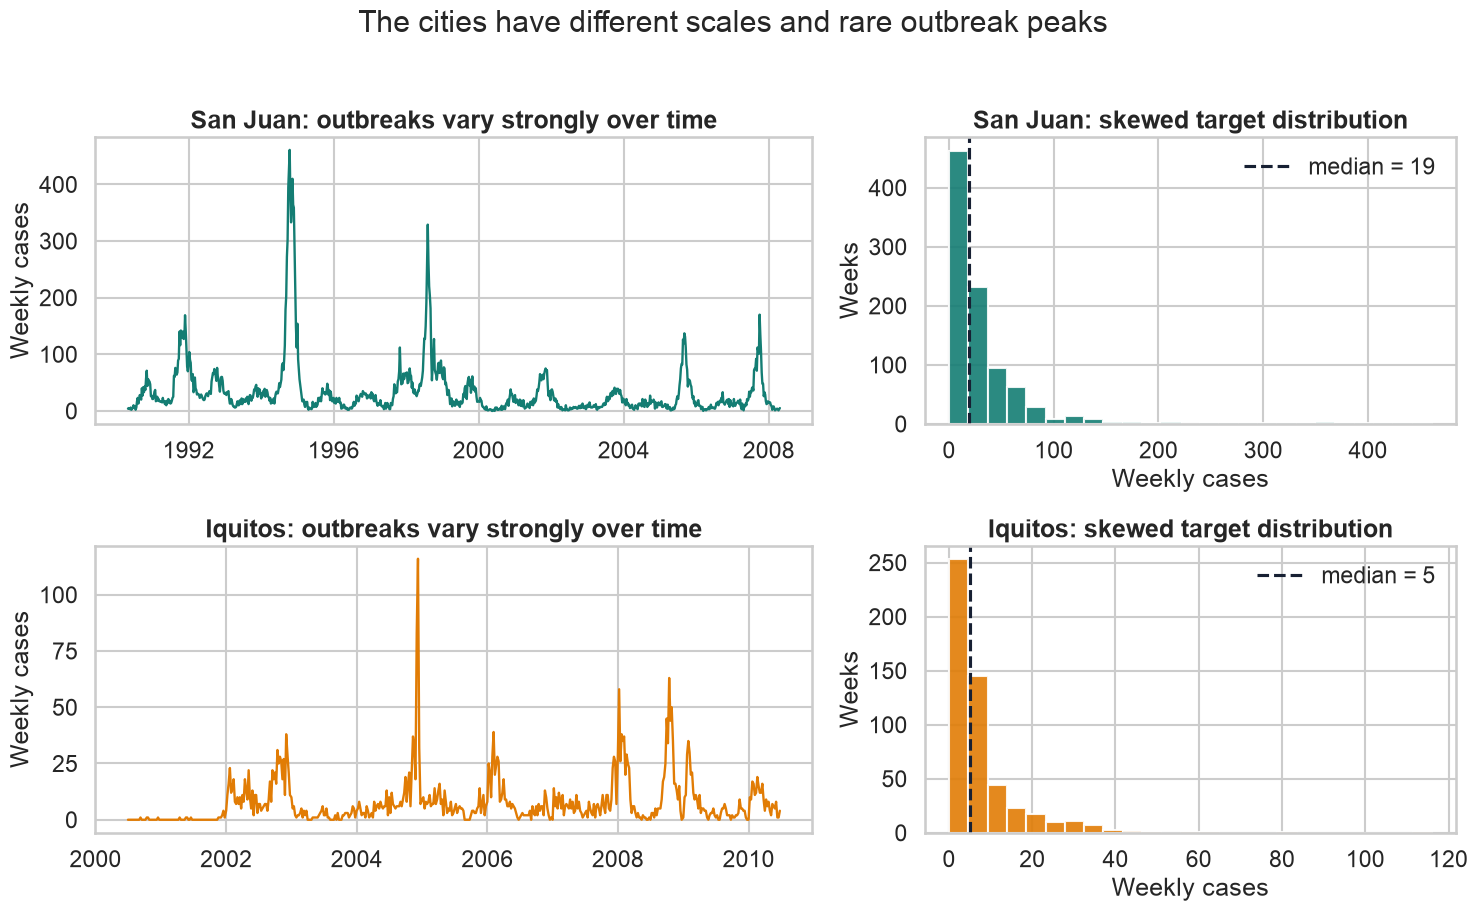

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), gridspec_kw={"width_ratios": [1.35, 1]})
for row, (city, name, color) in enumerate(
    [("sj", "San Juan", TEAL), ("iq", "Iquitos", ORANGE)]
):
    frame = train.loc[train.city.eq(city)].sort_values(DATE_COLUMN)
    axes[row, 0].plot(frame[DATE_COLUMN], frame[TARGET_COLUMN], color=color, lw=1.7)
    axes[row, 0].set(title=f"{name}: outbreaks vary strongly over time", ylabel="Weekly cases")
    axes[row, 0].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=9))
    axes[row, 0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axes[row, 0].xaxis.get_major_locator()))

    axes[row, 1].hist(frame[TARGET_COLUMN], bins=25, color=color, alpha=0.9)
    median = frame[TARGET_COLUMN].median()
    axes[row, 1].axvline(median, color=INK, ls="--", label=f"median = {median:.0f}")
    axes[row, 1].set(title=f"{name}: skewed target distribution", xlabel="Weekly cases", ylabel="Weeks")
    axes[row, 1].legend(frameon=False)

fig.suptitle("The cities have different scales and rare outbreak peaks", y=1.02)
fig.tight_layout()
plt.show()

### Decision 1 — fit city-specific models

- A shared model would be dominated by the larger San Juan peaks.
- Iquitos contains more low-count weeks, so a log-target forest is a reasonable stabilizing choice.
- San Juan needs enough output amplitude to represent rare outbreaks.

This motivates **San Juan Extra Trees** and **Iquitos Random Forest on `log1p(total_cases)`** in the first successful tree system.

## 4. Missing values: quantify first, then choose the treatment

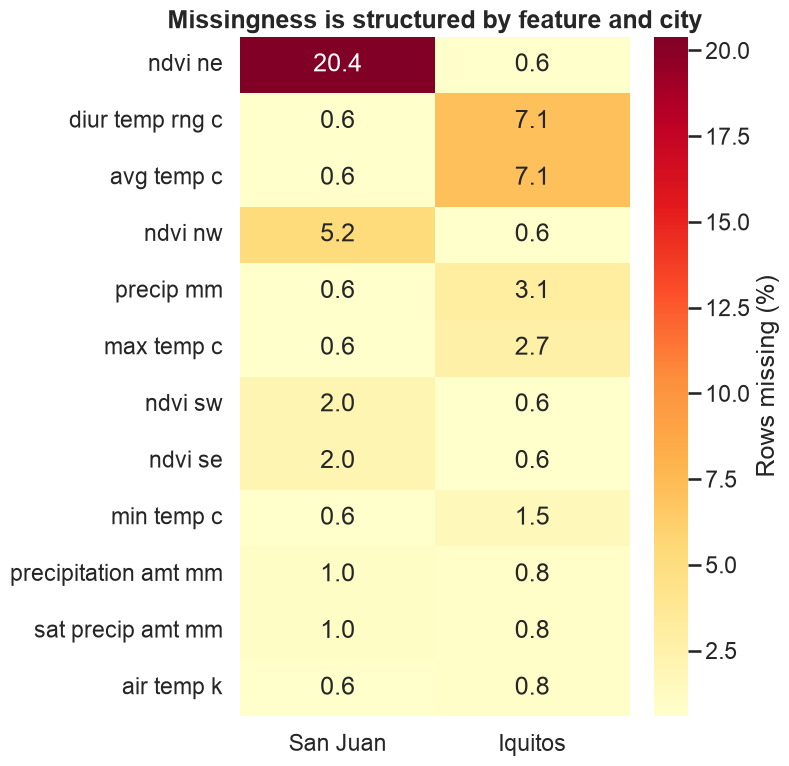

In [5]:
identifier_columns = {"year", "weekofyear", TARGET_COLUMN}
numeric_weather = [
    c for c in train.select_dtypes(include="number").columns if c not in identifier_columns
]
missing_by_city = train.groupby("city")[numeric_weather].apply(
    lambda frame: frame.isna().mean() * 100
)
top_missing = missing_by_city.max(axis=0).sort_values(ascending=False).head(12).index
missing_table = missing_by_city.loc[["sj", "iq"], top_missing].T

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    missing_table,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={"label": "Rows missing (%)"},
    ax=ax,
)
ax.set_xticklabels(["San Juan", "Iquitos"])
ax.set_yticklabels([x.replace("reanalysis_", "").replace("station_", "").replace("_", " ") for x in top_missing])
ax.set(title="Missingness is structured by feature and city", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

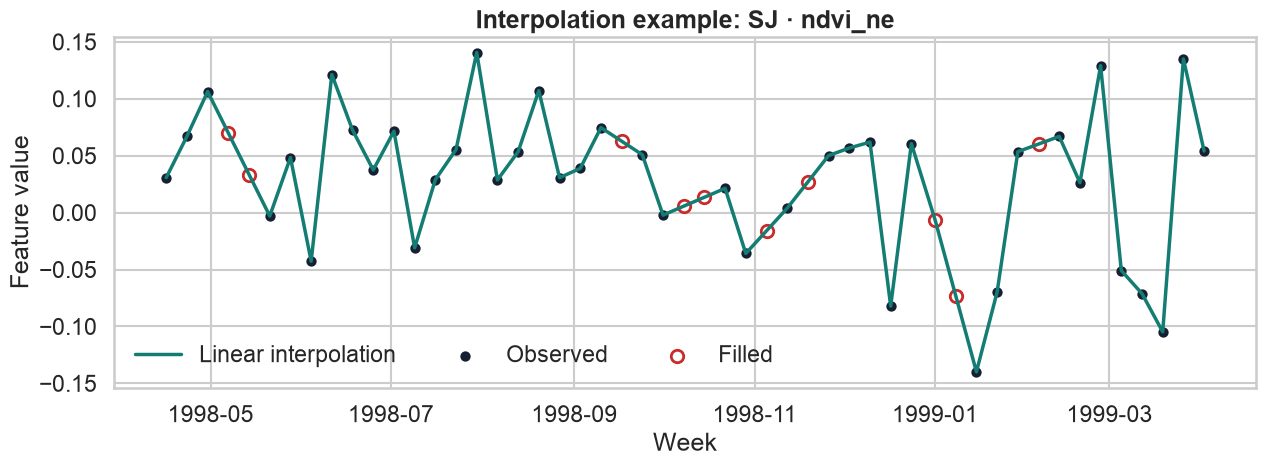

In [6]:
# Show what interpolation does on the feature with the highest missing share.
example_feature = top_missing[0]
example_city = missing_table.loc[example_feature].idxmax()
example = train.loc[train.city.eq(example_city)].sort_values(DATE_COLUMN).reset_index(drop=True)
raw = example[example_feature].astype(float)
filled = raw.interpolate(method="linear", limit_direction="both")
missing_positions = np.flatnonzero(raw.isna().to_numpy())
center = int(missing_positions[len(missing_positions) // 2])
window = slice(max(0, center - 25), min(len(example), center + 25))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(example.loc[window, DATE_COLUMN], filled.loc[window], color=TEAL, lw=2.5, label="Linear interpolation")
observed = raw.loc[window].notna()
window_index = raw.loc[window].index
ax.scatter(example.loc[window_index[observed], DATE_COLUMN], raw.loc[window_index[observed]], color=INK, s=35, label="Observed")
ax.scatter(
    example.loc[window_index[~observed], DATE_COLUMN],
    filled.loc[window_index[~observed]],
    facecolors="white", edgecolors=RED, linewidths=2, s=80, label="Filled"
)
ax.set(title=f"Interpolation example: {example_city.upper()} · {example_feature}", xlabel="Week", ylabel="Feature value")
ax.legend(frameon=False, ncol=3)
plt.tight_layout()
plt.show()

### Two treatments, because the representations are different

**Tree pipeline**

```text
feature construction → median imputer fitted on the training fold → forest
```

Median imputation is robust and sufficient for threshold-based trees.

**History MLP pipeline**

```text
weekly table → linear interpolation → normalization → lag/history matrix → MLP
```

Interpolation is useful here because a missing value otherwise becomes a hole repeated across many lag windows. For a production system, interpolation should be restricted to information available at prediction time; the repository preserves the confirmed competition workflow for reproducibility.

## 5. Normalization differs by model family

There are two preprocessing contracts—not one universal normalization rule.

| Component | Tree ensemble | History / multiscale MLP |
|---|---|---|
| Missing weather | Median imputer fitted inside each training fold | Linear interpolation before building histories |
| Weather inputs | **No scaling**; retain °C/K, mm, humidity, and NDVI units | Z-score each weather variable: $z=(x-\mu_{SJ})/\sigma_{SJ}$ |
| Calendar | Raw week plus sine/cosine harmonics | Week is min–max scaled in raw-history inputs; multiscale inputs use sine/cosine harmonics |
| City handling | Separate estimator for each city | Separate MLP for each city, while both use the confirmed SJ scaling parameters |
| Target | SJ: raw cases; IQ: $\log(1+y)$ during fitting and `expm1` after prediction | Raw weekly cases; the output layer is linear and training minimizes MAE |
| PLS extension | Not used | Four appended PLS scores are standardized using fold-training statistics |

### Why the tree path does not scale $X$

A tree asks order-based questions such as `humidity < threshold`. An affine
rescaling changes the numerical threshold but not the ordering of observations,
so it does not improve the split. Scaling would add another learned transform
without addressing the dominant tree problems: variance, temporal shift, and
missing outbreak amplitude. The median imputer remains necessary because the
scikit-learn forests in this project do not accept every missing value directly.

IQ's `log1p` operation is a **target transformation**, not feature normalization.
It reduces the influence of rare large case counts for the IQ Random Forest.
San Juan instead retains raw non-negative counts and uses Extra Trees with the
Poisson split criterion.

### Why the MLP path must scale $X$

Gradient-based learning sees numerical magnitude. Without scaling, precipitation
features measured in tens or hundreds can dominate NDVI values near zero, causing
poor conditioning and uneven weight updates. The MLP therefore standardizes each
weather channel before constructing raw histories or multiscale summaries:

\[
z_{t,j}=\frac{x_{t,j}-\mu_{SJ,j}}{\max(\sigma_{SJ,j},10^{-12})}.
\]

The default is deliberately called **shared-SJ normalization**: means and standard
deviations are estimated from the available San Juan training prefix and applied
to both cities. The models are still city-specific. This unusual choice is retained
because the controlled normalization ablation favored it; it is an empirical
compatibility choice, not a general recommendation. Within temporal validation,
the statistics are recomputed using only the fold's training prefix, preventing
validation-period leakage. The final test transformation uses full training data
only—never test outcomes.

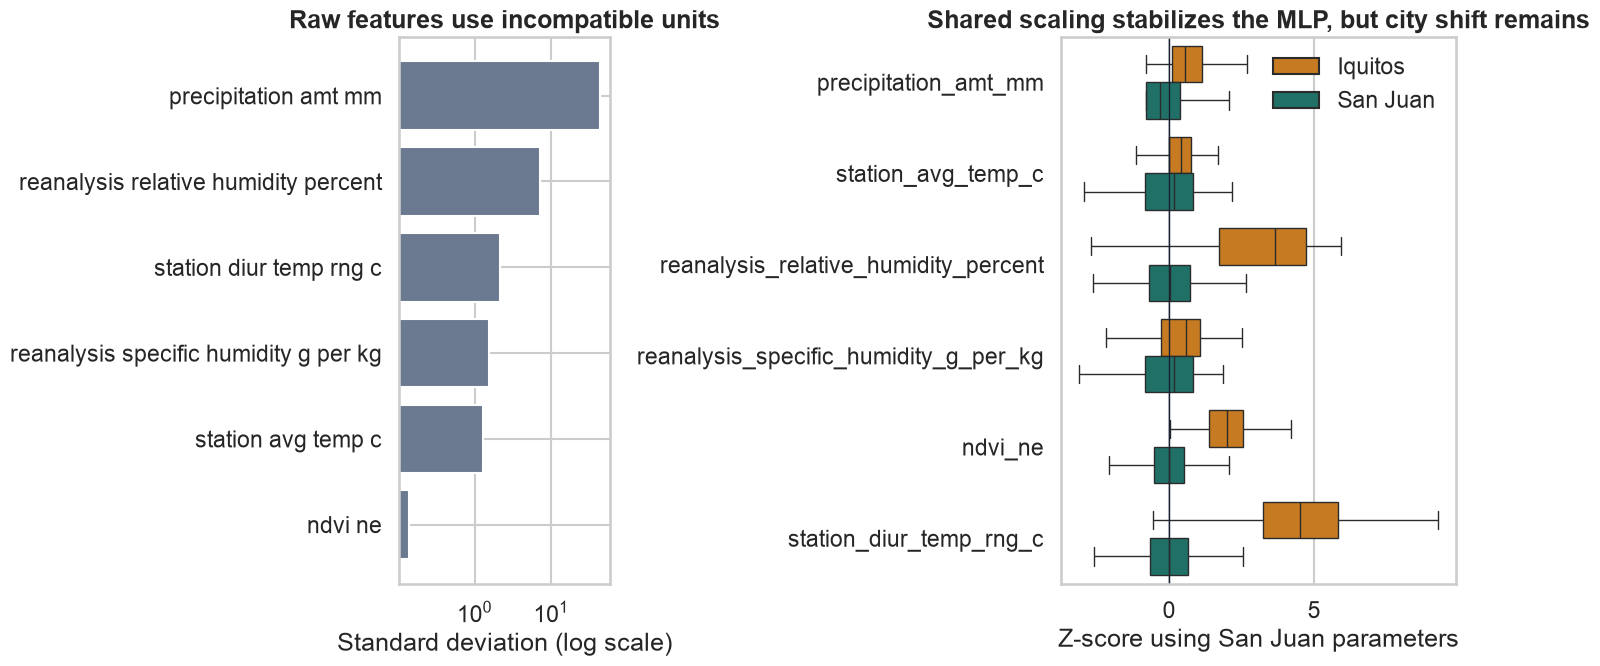

In [7]:
normalization_features = [
    "precipitation_amt_mm",
    "station_avg_temp_c",
    "reanalysis_relative_humidity_percent",
    "reanalysis_specific_humidity_g_per_kg",
    "ndvi_ne",
    "station_diur_temp_rng_c",
]
normalized_source = train.copy()
normalized_source[normalization_features] = normalized_source.groupby("city", sort=False)[normalization_features].transform(
    lambda frame: frame.interpolate(limit_direction="both")
)

# Reproduce the confirmed shared-SJ scaling choice.
sj_reference = normalized_source.loc[normalized_source.city.eq("sj"), normalization_features]
sj_mean = sj_reference.mean()
sj_std = sj_reference.std(ddof=0).replace(0, 1)

scaled_long = []
for city, frame in normalized_source.groupby("city"):
    z = (frame[normalization_features] - sj_mean) / sj_std
    scaled_long.append(
        z.assign(city={"sj": "San Juan", "iq": "Iquitos"}[city]).melt(
            id_vars="city", var_name="feature", value_name="z_score"
        )
    )
scaled_long = pd.concat(scaled_long, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [0.8, 1.5]})
raw_std = normalized_source[normalization_features].std(ddof=0).sort_values()
axes[0].barh(raw_std.index.str.replace("_", " "), raw_std, color=GRAY)
axes[0].set_xscale("log")
axes[0].set(title="Raw features use incompatible units", xlabel="Standard deviation (log scale)")

sns.boxplot(
    data=scaled_long,
    y="feature", x="z_score", hue="city", showfliers=False,
    palette={"San Juan": TEAL, "Iquitos": ORANGE}, ax=axes[1]
)
axes[1].axvline(0, color=INK, lw=1)
axes[1].set(title="Shared scaling stabilizes the MLP, but city shift remains", xlabel="Z-score using San Juan parameters", ylabel="")
axes[1].legend(frameon=False, title="")
fig.tight_layout()
plt.show()

**Interpretation:** MLP normalization fixes numerical conditioning; it does not
make San Juan and Iquitos statistically identical. The remaining orange/teal
offsets are useful evidence for separate city models. Meanwhile, trees keep the
raw units because split decisions depend on order rather than gradient magnitude.

## 6. Seasonality is real—but insufficient

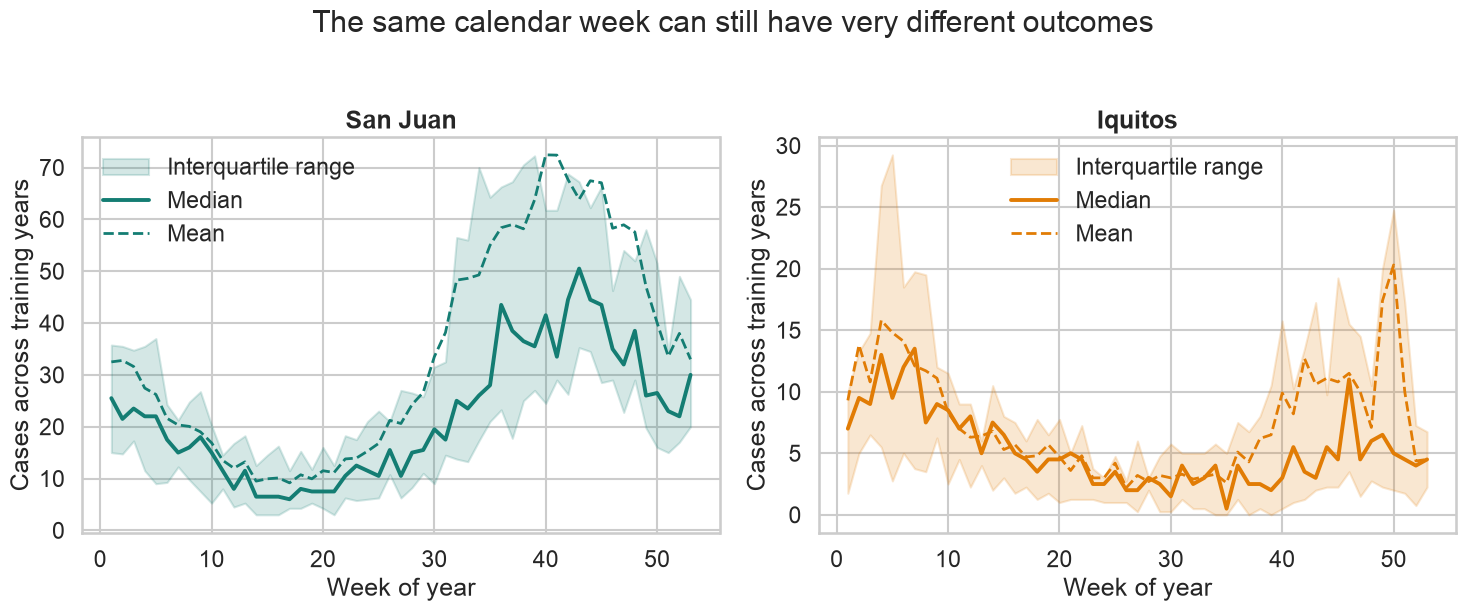

In [8]:
seasonal = (
    train.groupby(["city", "weekofyear"])[TARGET_COLUMN]
    .agg(
        mean="mean",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
for ax, (city, name, color) in zip(
    axes, [("sj", "San Juan", TEAL), ("iq", "Iquitos", ORANGE)]
):
    frame = seasonal.loc[seasonal.city.eq(city)]
    ax.fill_between(frame.weekofyear, frame.q25, frame.q75, color=color, alpha=0.18, label="Interquartile range")
    ax.plot(frame.weekofyear, frame["median"], color=color, lw=2.8, label="Median")
    ax.plot(frame.weekofyear, frame["mean"], color=color, lw=2, ls="--", label="Mean")
    ax.set(title=name, xlabel="Week of year", ylabel="Cases across training years")
    ax.legend(frameon=False)
fig.suptitle("The same calendar week can still have very different outcomes", y=1.03)
fig.tight_layout()
plt.show()

### Feature consequence

Raw week numbers create an artificial jump between weeks 52 and 1. The tree and MLP systems use cyclic coordinates:

\[
\sin(2\pi w/52),\quad \cos(2\pi w/52),\quad
\sin(4\pi w/52),\quad \cos(4\pi w/52)
\]

The wide seasonal bands show why calendar phase must be combined with climate history.

## 7. Validation must imitate forecasting

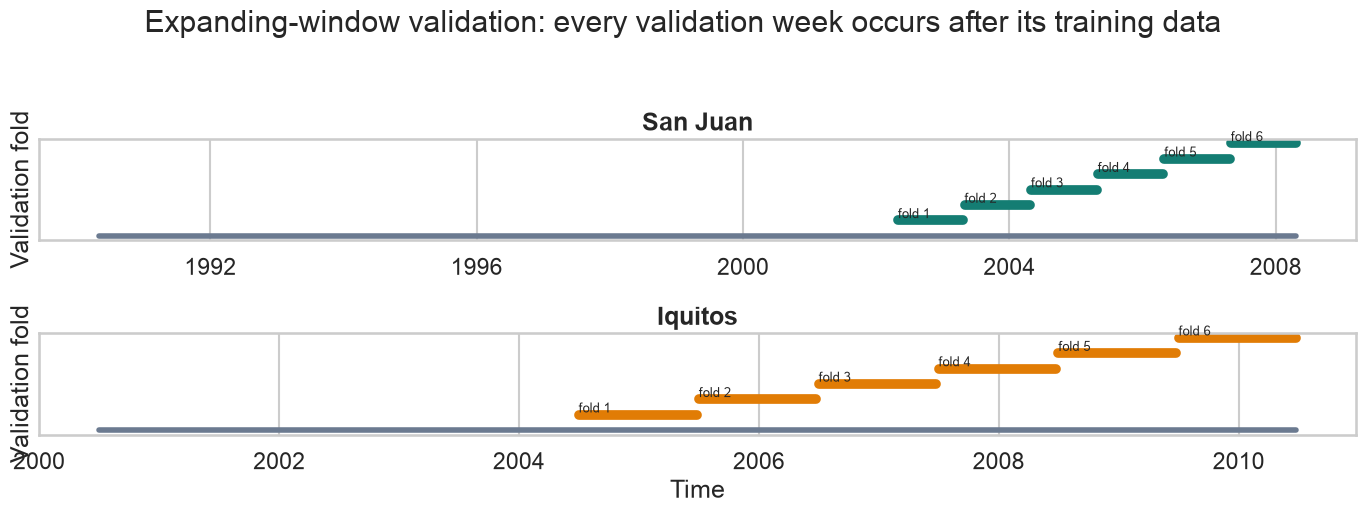

In [9]:
def annual_origins(frame: pd.DataFrame, fold_count: int = 6, horizon: int = 52) -> list[int]:
    # Expanding-window annual origins used in the tree experiments.
    return list(range(len(frame) - fold_count * horizon, len(frame), horizon))


fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=False)
for ax, (city, name, color) in zip(axes, [("sj", "San Juan", TEAL), ("iq", "Iquitos", ORANGE)]):
    frame = train.loc[train.city.eq(city)].sort_values(DATE_COLUMN).reset_index(drop=True)
    origins = annual_origins(frame)
    ax.plot(frame[DATE_COLUMN], np.zeros(len(frame)), color=GRAY, lw=4)
    for fold, start in enumerate(origins, 1):
        end = min(start + 52, len(frame))
        ax.plot(frame.loc[start:end-1, DATE_COLUMN], np.full(end-start, fold), color=color, lw=7)
        ax.text(frame.loc[start, DATE_COLUMN], fold + 0.15, f"fold {fold}", fontsize=9)
    ax.set(title=name, ylabel="Validation fold", yticks=[])
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=10))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
axes[-1].set_xlabel("Time")
fig.suptitle("Expanding-window validation: every validation week occurs after its training data", y=1.04)
fig.tight_layout()
plt.show()

Random train/validation splits would let the model train on future climate regimes and validate on the past. Annual expanding windows are harder but closer to the competition setting. Fold means, fold variation, outbreak MAE, bias, and peak amplitude are all useful—one pooled MAE is not enough.

## 8. Baselines: forests versus boosting

,city,family,configuration,validation_mae,fold_std,outbreak_mae,prediction_max
0,SJ,Forest,tree,13.96,2.64,45.19,79.0
1,SJ,CatBoost,cat_mae_d4,13.45,4.09,36.33,118.0
2,SJ,XGBoost,xgb_mae_d2,14.42,4.68,51.10,74.0
3,IQ,Forest,tree,6.21,2.94,27.64,13.0
4,IQ,CatBoost,cat_poisson_d4,6.17,3.25,27.41,14.0
5,IQ,XGBoost,xgb_poisson_d3,6.26,2.86,25.95,16.0


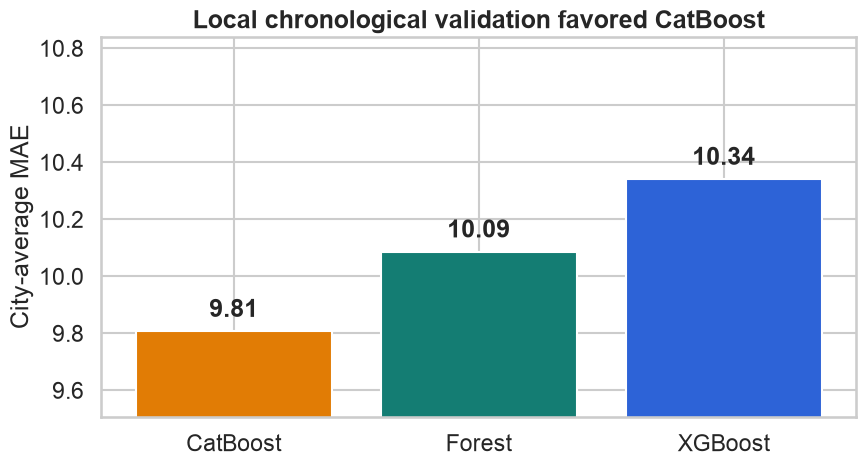

In [10]:
def read_csv_from_git(ref: str, repository_path: str) -> pd.DataFrame:
    # Read a committed experiment artifact without changing the working tree.
    payload = subprocess.check_output(
        ["git", "-C", str(PROJECT_ROOT), "show", f"{ref}:{repository_path}"],
        text=True,
    )
    return pd.read_csv(io.StringIO(payload))


boosting_search = read_csv_from_git("refactor", "artifacts/boosting_search_results.csv")
pure_models = boosting_search.loc[
    boosting_search.boosting_weight.eq(1.0) | boosting_search.candidate.eq("tree")
].copy()

family_name = {"tree": "Forest", "catboost": "CatBoost", "xgboost": "XGBoost"}
best_pure_rows = []
for city in ["sj", "iq"]:
    city_results = pure_models.loc[pure_models.city.eq(city)]
    for family in family_name:
        best = city_results.loc[city_results.family.eq(family)].sort_values("pooled_mae").iloc[0]
        best_pure_rows.append(
            {
                "city": city.upper(),
                "family": family_name[family],
                "configuration": best.candidate,
                "validation_mae": best.pooled_mae,
                "fold_std": best.std_fold_mae,
                "outbreak_mae": best.outbreak_mae,
                "prediction_max": best.prediction_max,
            }
        )

best_pure = pd.DataFrame(best_pure_rows)
display(best_pure.round(2))

city_average = best_pure.groupby("family").validation_mae.mean().sort_values()
colors = {"Forest": TEAL, "CatBoost": ORANGE, "XGBoost": BLUE}
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(city_average.index, city_average.values, color=[colors[x] for x in city_average.index])
ax.set(title="Local chronological validation favored CatBoost", ylabel="City-average MAE")
ax.set_ylim(city_average.min() - 0.3, city_average.max() + 0.5)
for bar, value in zip(bars, city_average.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.05, f"{value:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### What the saved experiment actually supports

- CatBoost was the strongest pure family in the saved four-fold city-average result.
- XGBoost did **not** beat the forest overall in that exact artifact, although some boosting configurations won individual city/fold comparisons.
- The project record says the forest generalized better on the hidden competition period; exact hidden CatBoost/XGBoost MAEs were not stored.

The defensible conclusion is therefore **ranking instability across time**, consistent with distribution shift and model-selection overfit—not a blanket statement that boosting always overfits.

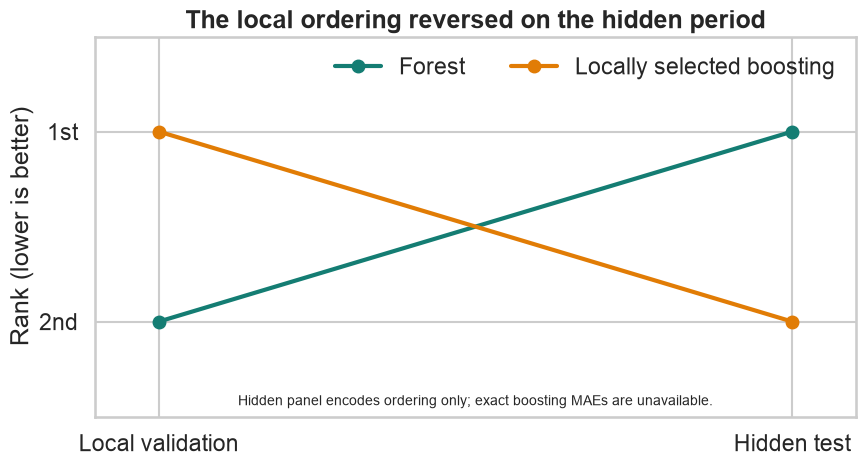

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot([0, 1], [2, 1], marker="o", lw=3, color=TEAL, label="Forest")
ax.plot([0, 1], [1, 2], marker="o", lw=3, color=ORANGE, label="Locally selected boosting")
ax.set(
    xlim=(-0.1, 1.1), ylim=(2.5, 0.5),
    xticks=[0, 1], xticklabels=["Local validation", "Hidden test"],
    yticks=[1, 2], yticklabels=["1st", "2nd"], ylabel="Rank (lower is better)",
    title="The local ordering reversed on the hidden period",
)
ax.legend(frameon=False, ncol=2)
ax.text(0.5, 0.03, "Hidden panel encodes ordering only; exact boosting MAEs are unavailable.", transform=ax.transAxes, ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 9. Why Extra Trees was the first variance-control move

In [12]:
from train_tree_ensemble import make_features

sj_frame = train.loc[train.city.eq("sj")].sort_values(DATE_COLUMN).reset_index(drop=True)
sj_features = make_features(sj_frame)
sj_target = sj_frame[TARGET_COLUMN].to_numpy(float)
sj_origins = annual_origins(sj_frame)

model_factories = {
    "Single tree": lambda: make_pipeline(
        SimpleImputer(strategy="median"),
        DecisionTreeRegressor(criterion="poisson", min_samples_leaf=5, random_state=42),
    ),
    "Random forest": lambda: make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestRegressor(
            n_estimators=100, criterion="poisson", min_samples_leaf=5,
            max_features=0.7, n_jobs=-1, random_state=42,
        ),
    ),
    "Extra Trees": lambda: make_pipeline(
        SimpleImputer(strategy="median"),
        ExtraTreesRegressor(
            n_estimators=100, criterion="poisson", min_samples_leaf=5,
            max_features=0.7, n_jobs=-1, random_state=42,
        ),
    ),
}

benchmark_rows = []
for model_name, factory in model_factories.items():
    for fold, start in enumerate(sj_origins, 1):
        model = factory()
        model.fit(sj_features.iloc[:start], sj_target[:start])
        benchmark_rows.append(
            {
                "model": model_name,
                "fold": fold,
                "train_mae": mean_absolute_error(sj_target[:start], model.predict(sj_features.iloc[:start])),
                "validation_mae": mean_absolute_error(
                    sj_target[start:start+52], model.predict(sj_features.iloc[start:start+52])
                ),
            }
        )

tree_benchmark = pd.DataFrame(benchmark_rows)
tree_summary = tree_benchmark.groupby("model").agg(
    train_mae=("train_mae", "mean"),
    validation_mae=("validation_mae", "mean"),
    validation_std=("validation_mae", "std"),
)
tree_summary.round(2)

,train_mae,validation_mae,validation_std
model,,,
Extra Trees,6.45,15.89,5.73
Random forest,8.10,18.34,5.91
Single tree,6.46,21.92,4.54


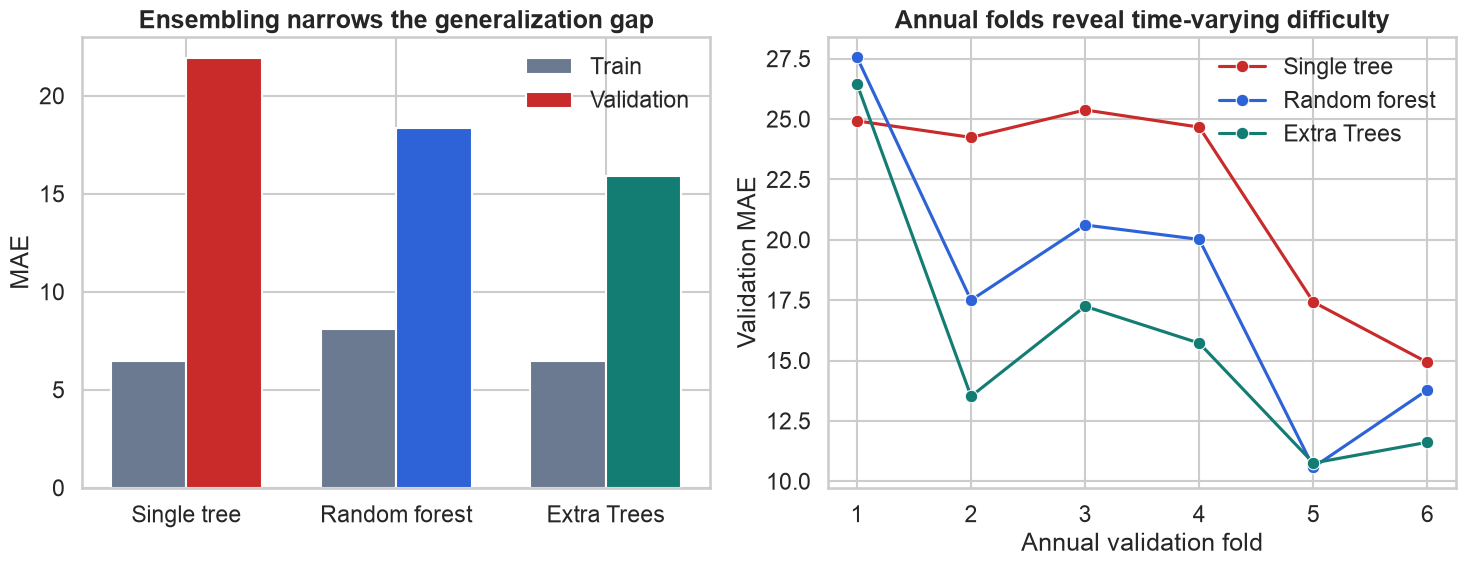

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
order = ["Single tree", "Random forest", "Extra Trees"]
x = np.arange(len(order))
w = 0.36
axes[0].bar(x-w/2, tree_summary.loc[order, "train_mae"], w, color=GRAY, label="Train")
axes[0].bar(x+w/2, tree_summary.loc[order, "validation_mae"], w, color=[RED, BLUE, TEAL], label="Validation")
axes[0].set(xticks=x, xticklabels=order, ylabel="MAE", title="Ensembling narrows the generalization gap")
axes[0].legend(frameon=False)

sns.lineplot(
    data=tree_benchmark,
    x="fold", y="validation_mae", hue="model", marker="o",
    hue_order=order, palette={"Single tree": RED, "Random forest": BLUE, "Extra Trees": TEAL},
    ax=axes[1],
)
axes[1].set(title="Annual folds reveal time-varying difficulty", xlabel="Annual validation fold", ylabel="Validation MAE")
axes[1].legend(frameon=False, title="")
fig.tight_layout()
plt.show()

### Why Extra Trees can help

Extra Trees randomizes both the feature subset and the candidate split threshold. This decorrelates individual trees. Averaging decorrelated prediction errors reduces estimator variance, while the five-sample minimum leaf prevents extremely specific rules.

The final San Juan tree used 500 Extra Trees with Poisson splitting. Iquitos used a 500-tree Random Forest on `log1p(total_cases)`, because the smaller, more zero-heavy target benefited from target stabilization.

## 10. Error analysis: the baseline misses outbreak amplitude

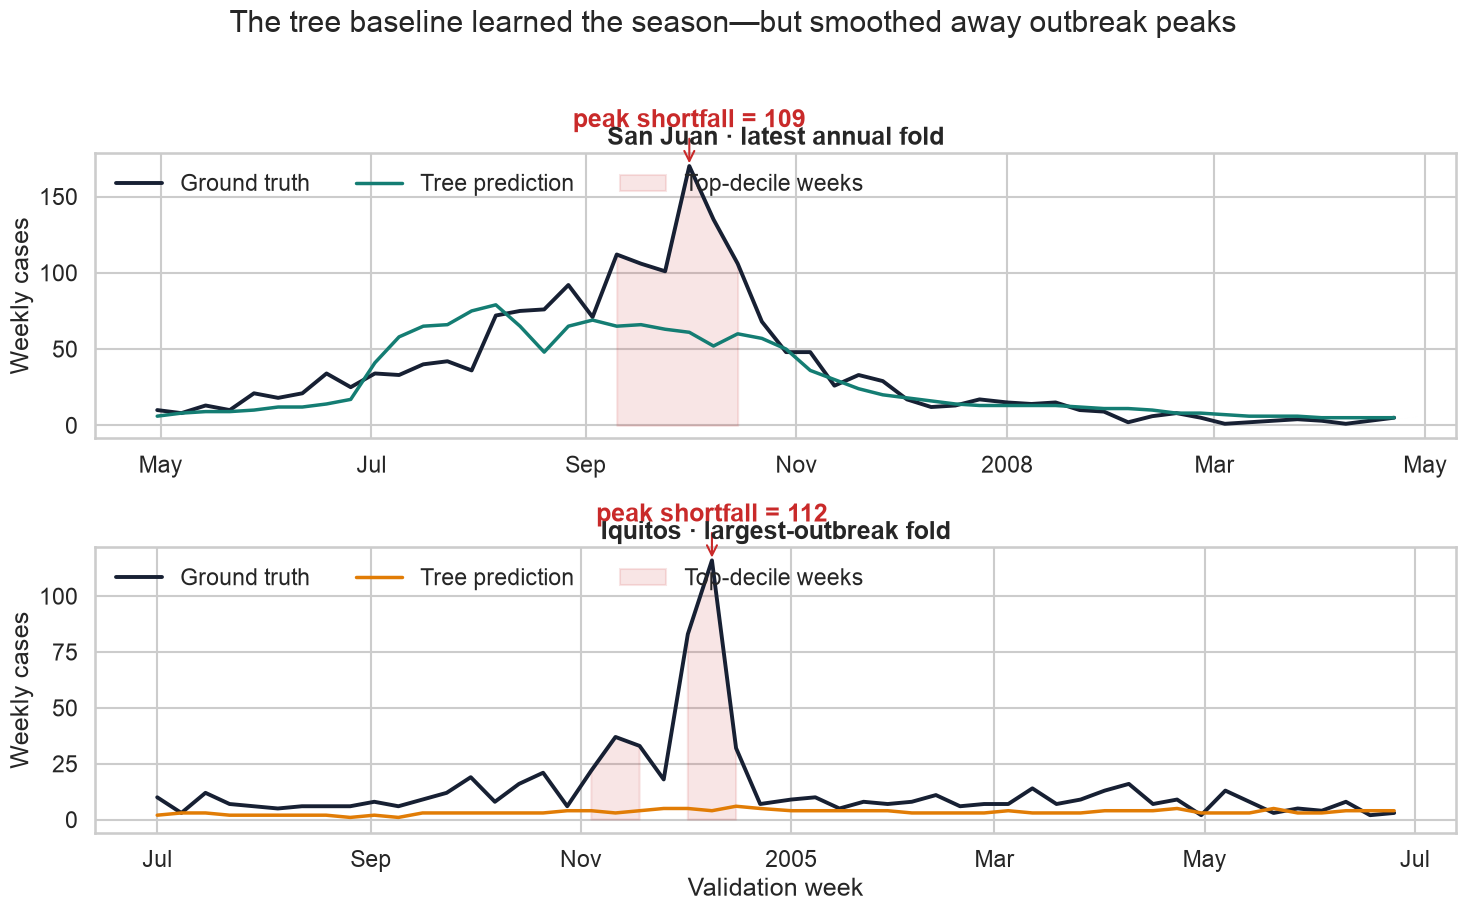

,city,fold,mae,peak_actual,peak_prediction,peak_shortfall,top_decile_error_share
0,SJ,6,13.942,170,61,109,0.501
1,IQ,1,10.635,116,4,112,0.537


In [14]:
tree_predictions = pd.read_csv(
    ARTIFACT_DIR / "tree_validation_predictions.csv", parse_dates=[DATE_COLUMN]
)
selected_folds = [("sj", 6, "San Juan · latest annual fold"), ("iq", 1, "Iquitos · largest-outbreak fold")]

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
error_rows = []
for ax, (city, fold, title) in zip(axes, selected_folds):
    frame = tree_predictions.loc[
        tree_predictions.city.eq(city) & tree_predictions.fold.eq(fold)
    ].sort_values(DATE_COLUMN)
    threshold = frame.actual.quantile(0.90)
    outbreak = frame.actual.ge(threshold)
    absolute_error = (frame.actual - frame.tree_prediction).abs()
    peak = frame.loc[frame.actual.idxmax()]
    error_rows.append(
        {
            "city": city.upper(),
            "fold": fold,
            "mae": absolute_error.mean(),
            "peak_actual": peak.actual,
            "peak_prediction": peak.tree_prediction,
            "peak_shortfall": peak.actual - peak.tree_prediction,
            "top_decile_error_share": absolute_error.loc[outbreak].sum() / absolute_error.sum(),
        }
    )

    ax.plot(frame[DATE_COLUMN], frame.actual, color=INK, lw=2.8, label="Ground truth")
    ax.plot(frame[DATE_COLUMN], frame.tree_prediction, color=TEAL if city == "sj" else ORANGE, lw=2.5, label="Tree prediction")
    ax.fill_between(frame[DATE_COLUMN], 0, frame.actual, where=outbreak, color=RED, alpha=0.12, label="Top-decile weeks")
    ax.annotate(
        f"peak shortfall = {peak.actual - peak.tree_prediction:.0f}",
        xy=(peak[DATE_COLUMN], peak.actual), xytext=(0, 28), textcoords="offset points",
        ha="center", color=RED, fontweight="bold", arrowprops={"arrowstyle": "->", "color": RED},
    )
    ax.set(title=title, ylabel="Weekly cases")
    ax.legend(frameon=False, ncol=3, loc="upper left")
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=9))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
axes[-1].set_xlabel("Validation week")
fig.suptitle("The tree baseline learned the season—but smoothed away outbreak peaks", y=1.02)
fig.tight_layout()
plt.show()

pd.DataFrame(error_rows).round(3)

### How we found the representation problem

The predictions are not random: they broadly follow the seasonal rise and fall. The dominant failure is **amplitude during a small number of outbreak weeks**. Weather during the exact peak week is often not extreme. That suggests the model is looking at the wrong temporal description, not simply missing another same-week interaction.

This leads to the epidemiological hypothesis:

> Rainfall, temperature, humidity, mosquito development, viral incubation, and human infection operate over delayed and accumulated timescales.

## 11. The clue: climate signal appears at different lags

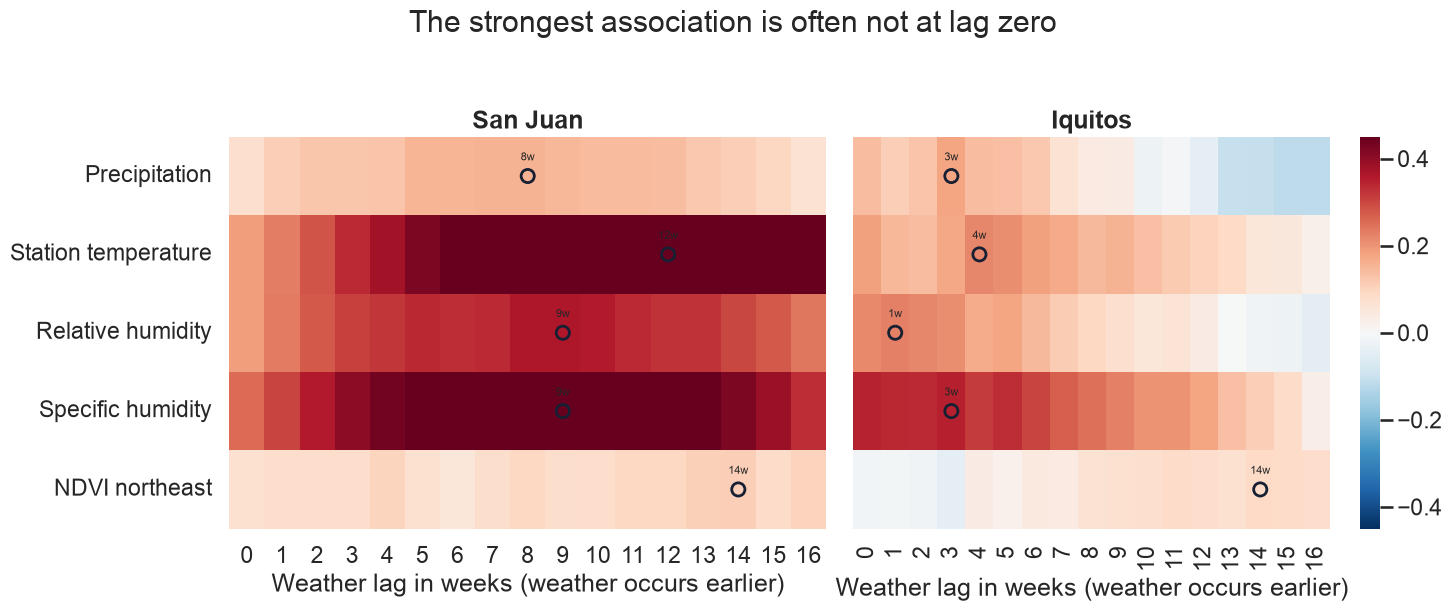

In [15]:
lag_features = {
    "precipitation_amt_mm": "Precipitation",
    "station_avg_temp_c": "Station temperature",
    "reanalysis_relative_humidity_percent": "Relative humidity",
    "reanalysis_specific_humidity_g_per_kg": "Specific humidity",
    "ndvi_ne": "NDVI northeast",
}
lags = np.arange(17)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
lag_tables = {}
for ax, (city, name) in zip(axes, [("sj", "San Juan"), ("iq", "Iquitos")]):
    frame = train.loc[train.city.eq(city)].sort_values(DATE_COLUMN).reset_index(drop=True)
    weather = frame[list(lag_features)].interpolate(limit_direction="both")
    y = np.log1p(frame[TARGET_COLUMN].astype(float))
    values = pd.DataFrame(index=lag_features.values(), columns=lags, dtype=float)
    for feature, label in lag_features.items():
        for lag in lags:
            values.loc[label, lag] = y.corr(weather[feature].shift(lag))
    lag_tables[city] = values
    sns.heatmap(values, cmap="RdBu_r", center=0, vmin=-0.45, vmax=0.45, cbar=city == "iq", ax=ax)
    ax.set(title=name, xlabel="Weather lag in weeks (weather occurs earlier)", ylabel="")
    for row, label in enumerate(values.index):
        best_lag = values.loc[label].abs().idxmax()
        ax.scatter(best_lag + 0.5, row + 0.5, s=90, facecolors="none", edgecolors=INK, linewidths=2)
        ax.text(best_lag + 0.5, row + 0.30, f"{best_lag}w", ha="center", fontsize=8)
fig.suptitle("The strongest association is often not at lag zero", y=1.03)
fig.tight_layout()
plt.show()

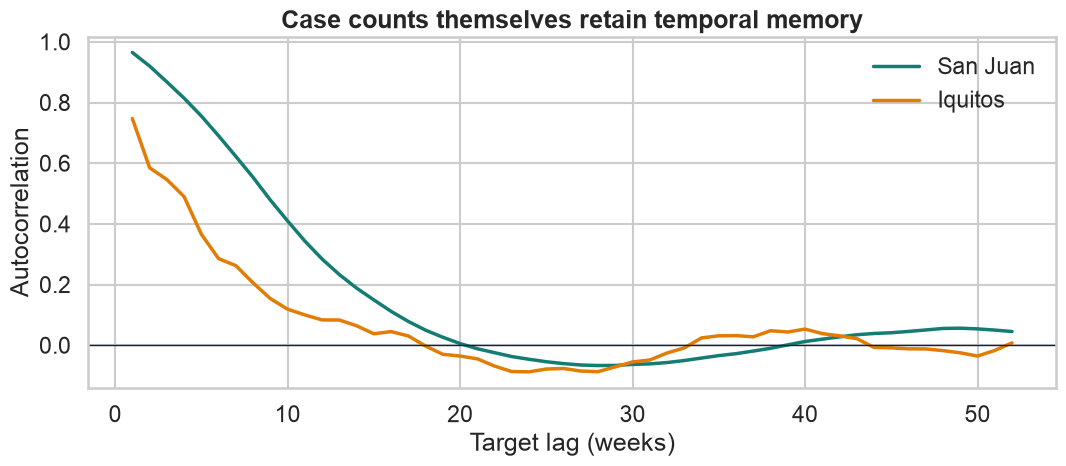

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))
for city, name, color in [("sj", "San Juan", TEAL), ("iq", "Iquitos", ORANGE)]:
    series = train.loc[train.city.eq(city)].sort_values(DATE_COLUMN)[TARGET_COLUMN].astype(float)
    autocorr = [series.autocorr(lag=lag) for lag in range(1, 53)]
    ax.plot(range(1, 53), autocorr, lw=2.5, label=name, color=color)
ax.axhline(0, color=INK, lw=1)
ax.set(title="Case counts themselves retain temporal memory", xlabel="Target lag (weeks)", ylabel="Autocorrelation")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Caution:** lagged correlation is exploratory evidence, not a causal estimate. It justifies testing past-only representations. The best lag differs by variable and city, so a single fixed offset is unlikely to be sufficient.

## 12. First feature-engineering response: sparse lags and rolling exposure

In [17]:
tree_feature_frame = make_features(sj_frame)

def feature_group(column: str) -> str:
    if "__lag_" in column:
        return "Sparse lag"
    if "__past_mean_" in column:
        return "Past rolling mean"
    if column.startswith("week_sin_") or column.startswith("week_cos_"):
        return "Season harmonic"
    if column in sj_frame.columns:
        return "Current measurement"
    return "Engineered interaction/summary"

feature_inventory = pd.Series(tree_feature_frame.columns).map(feature_group).value_counts().rename("feature_count")
feature_inventory.to_frame()

,feature_count
Sparse lag,54
Past rolling mean,45
Current measurement,22
Season harmonic,8
Engineered interaction/summary,5


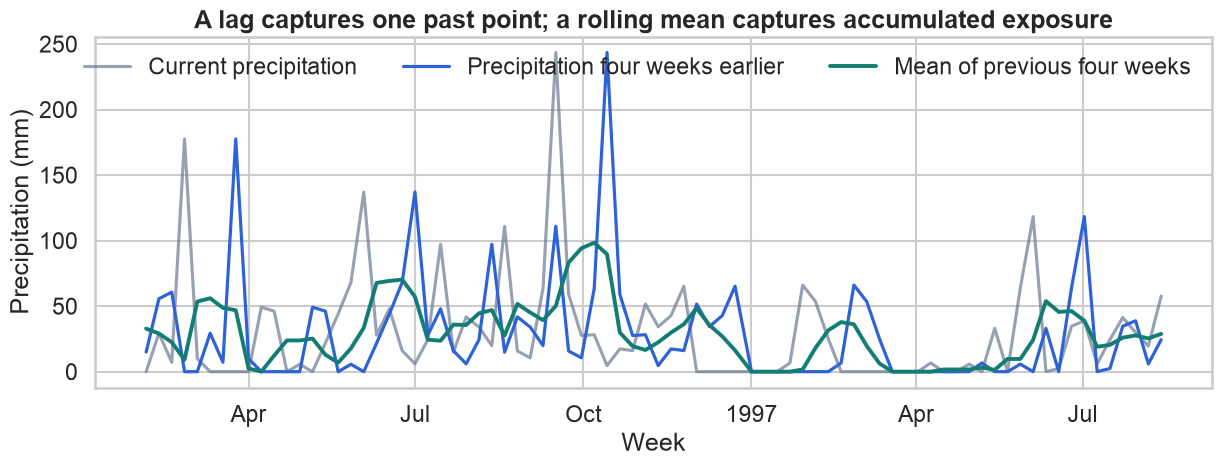

In [18]:
example = sj_frame[[DATE_COLUMN, "precipitation_amt_mm"]].copy()
example["lag_4"] = example.precipitation_amt_mm.shift(4)
example["past_mean_4"] = example.precipitation_amt_mm.shift(1).rolling(4).mean()
example = example.iloc[300:380]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(example[DATE_COLUMN], example.precipitation_amt_mm, color=GRAY, alpha=0.7, label="Current precipitation")
ax.plot(example[DATE_COLUMN], example.lag_4, color=BLUE, lw=2.3, label="Precipitation four weeks earlier")
ax.plot(example[DATE_COLUMN], example.past_mean_4, color=TEAL, lw=2.8, label="Mean of previous four weeks")
ax.set(title="A lag captures one past point; a rolling mean captures accumulated exposure", xlabel="Week", ylabel="Precipitation (mm)")
ax.legend(frameon=False, ncol=3)
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=9))
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.tight_layout()
plt.show()

This city-specific tree system reached **22.5 hidden-test MAE**. It proved that seasonality, nonlinear thresholds, and delayed exposure matter. Its limitation was that history was sampled only at lags 1/2/4/8/12/16 and a few rolling windows. Behavior between those positions could still be missed.

## 13. V11/raw-history MLP: preserve continuous memory

In [19]:
from feature_lag_mlp.data import load_competition_data
from feature_lag_mlp.representations import (
    MULTISCALE_SUMMARIES,
    RAW_LAGS,
    RAW_PLUS_SUMMARIES,
    build_representation_training_matrix,
)

pipeline_train, pipeline_test, pipeline_template = load_competition_data(DATA_DIR)
representation_rows = []
representation_matrices = {}
for city in ["sj", "iq"]:
    for representation in [RAW_LAGS, MULTISCALE_SUMMARIES, RAW_PLUS_SUMMARIES]:
        matrix, target = build_representation_training_matrix(
            pipeline_train, city, representation
        )
        representation_matrices[(city, representation)] = (matrix, target)
        representation_rows.append(
            {
                "city": city.upper(),
                "representation": representation,
                "rows": matrix.shape[0],
                "input_features": matrix.shape[1],
            }
        )

pd.DataFrame(representation_rows)

,city,representation,rows,input_features
0,SJ,raw_lags,936,461
1,SJ,multiscale_summaries,936,180
2,SJ,raw_plus_summaries,936,641
3,IQ,raw_lags,520,380
4,IQ,multiscale_summaries,520,180
5,IQ,raw_plus_summaries,520,560


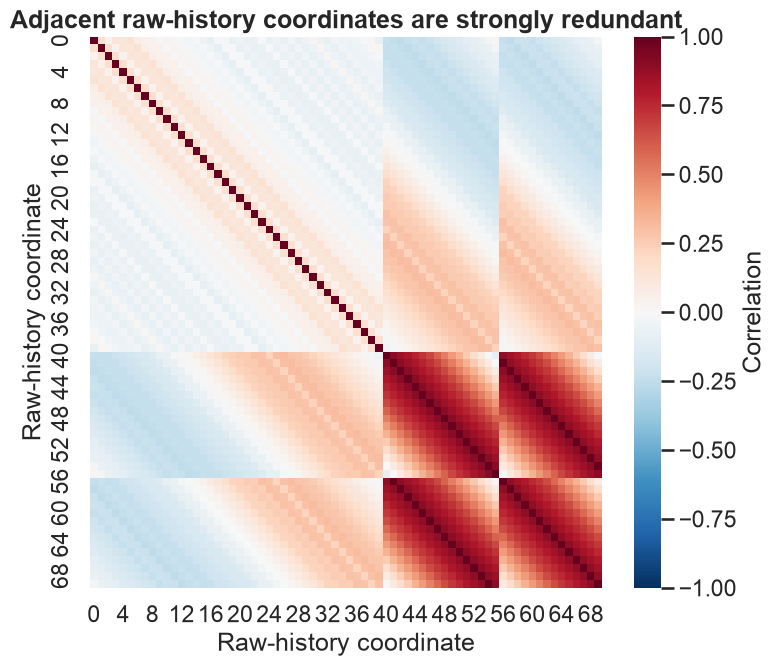

Mean absolute correlation of adjacent coordinates in this block: 0.458


In [20]:
raw_sj, raw_sj_target = representation_matrices[("sj", RAW_LAGS)]

# The first 70 coordinates contain several consecutive values from the first
# weather histories. Their correlation illustrates redundancy in raw lags.
subset = raw_sj[:, :70]
corr = np.corrcoef(subset, rowvar=False)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, cbar_kws={"label": "Correlation"}, ax=ax)
ax.set(title="Adjacent raw-history coordinates are strongly redundant", xlabel="Raw-history coordinate", ylabel="Raw-history coordinate")
plt.tight_layout()
plt.show()

adjacent_correlation = np.nanmean(np.abs(np.diag(corr, k=1)))
print(f"Mean absolute correlation of adjacent coordinates in this block: {adjacent_correlation:.3f}")

### Why raw histories improved to the 19-ish MAE range

The MLP receives every retained weekly value instead of sparse samples. It can learn nonlinear combinations across the infection/vector-development horizon.

```text
San Juan: 461 inputs → Dense 100 → Dense 25 → prediction
Iquitos: 380 inputs → Dense 70  → Dense 18 → prediction
```

But San Juan has only 936 labels. Hundreds of adjacent, highly correlated coordinates create a noisy, high-dimensional problem. V11-style dropout helps regularize the network, but it cannot remove redundancy from the input representation.

## 14. Multiscale summaries: compress history into epidemiologically useful views

For each of 16 weather variables, the final representation computes:

```text
current value
+ means over 2, 4, 8, 13, 26, and 52 weeks
+ standard deviations over 4 and 13 weeks
+ 4-week mean minus 13-week mean
+ 13-week trend
```

Then it adds four cyclic season features:

```text
16 weather variables × 11 summaries + 4 season coordinates = 180 inputs
```

Short windows detect recent changes; medium windows encode delayed/cumulative conditions; long windows provide seasonal background.

,representation,SJ validation MAE,IQ validation MAE,SJ inputs,IQ inputs
0,Raw histories,17.86,7.85,461,380
1,Multiscale summaries,12.61,7.39,180,180
2,Raw + summaries,18.43,7.95,641,560


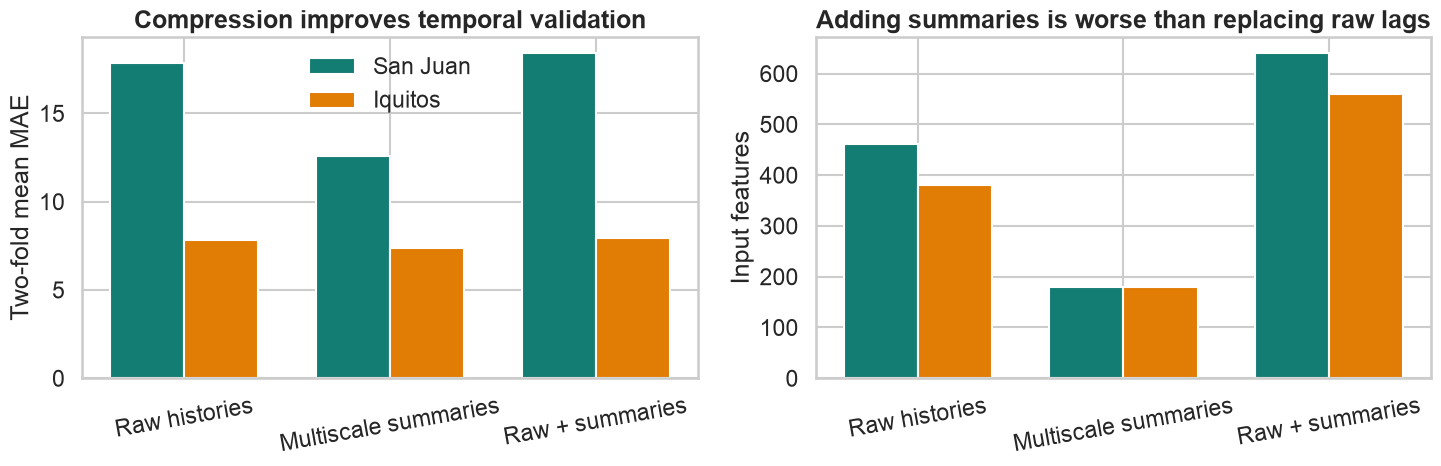

In [21]:
ablation = pd.DataFrame(
    {
        "representation": ["Raw histories", "Multiscale summaries", "Raw + summaries"],
        "SJ validation MAE": [17.86, 12.61, 18.43],
        "IQ validation MAE": [7.85, 7.39, 7.95],
        "SJ inputs": [461, 180, 641],
        "IQ inputs": [380, 180, 560],
    }
)
display(ablation)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(ablation))
w = 0.36
axes[0].bar(x-w/2, ablation["SJ validation MAE"], w, color=TEAL, label="San Juan")
axes[0].bar(x+w/2, ablation["IQ validation MAE"], w, color=ORANGE, label="Iquitos")
axes[0].set(xticks=x, xticklabels=ablation.representation, ylabel="Two-fold mean MAE", title="Compression improves temporal validation")
axes[0].tick_params(axis="x", rotation=10)
axes[0].legend(frameon=False)

axes[1].bar(x-w/2, ablation["SJ inputs"], w, color=TEAL, label="San Juan")
axes[1].bar(x+w/2, ablation["IQ inputs"], w, color=ORANGE, label="Iquitos")
axes[1].set(xticks=x, xticklabels=ablation.representation, ylabel="Input features", title="Adding summaries is worse than replacing raw lags")
axes[1].tick_params(axis="x", rotation=10)
fig.tight_layout()
plt.show()

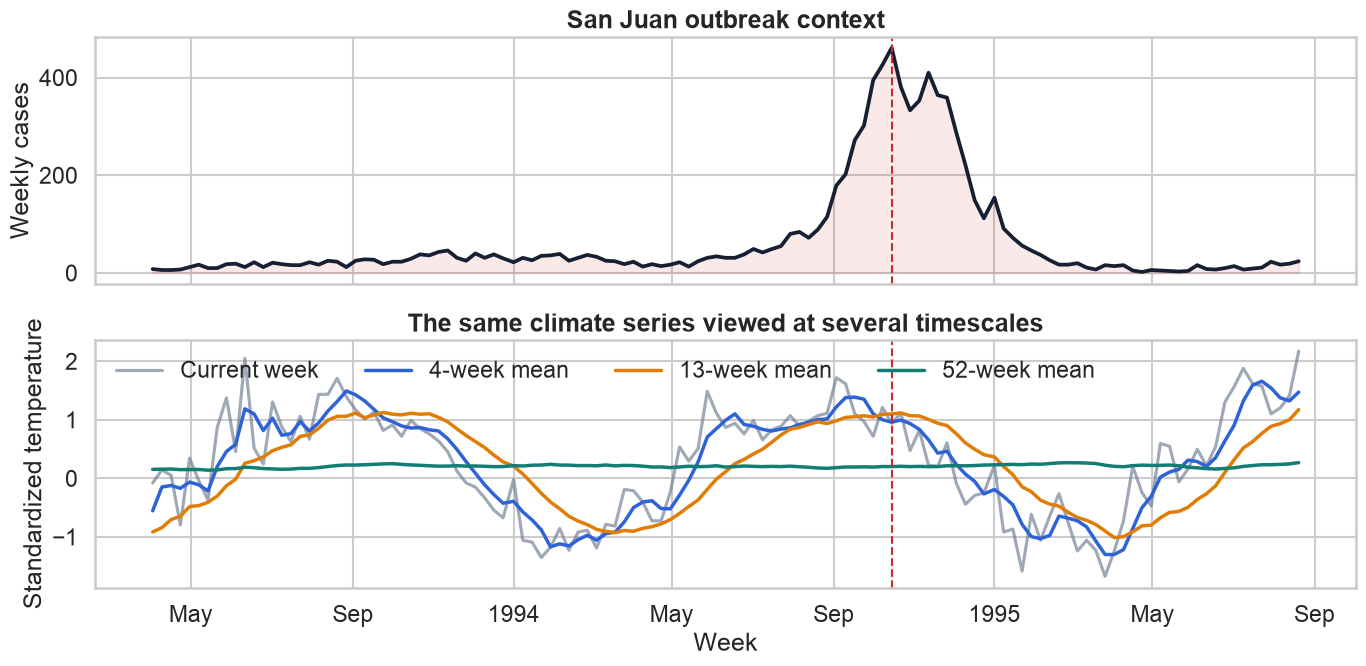

In [22]:
# A concrete view of why several timescales are different information.
context = sj_frame.copy()
climate_feature = "station_avg_temp_c"
series = context[climate_feature].interpolate(limit_direction="both")
z = (series - series.mean()) / series.std(ddof=0)
for window in [4, 13, 52]:
    context[f"mean_{window}"] = z.rolling(window, min_periods=1).mean()
context["current_z"] = z

peak_index = int(context[TARGET_COLUMN].idxmax())
left, right = max(0, peak_index - 80), min(len(context), peak_index + 45)
sample = context.iloc[left:right]
peak_date = context.loc[peak_index, DATE_COLUMN]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(sample[DATE_COLUMN], sample[TARGET_COLUMN], color=INK, lw=2.7)
axes[0].fill_between(sample[DATE_COLUMN], 0, sample[TARGET_COLUMN], color=RED, alpha=0.10)
axes[0].set(title="San Juan outbreak context", ylabel="Weekly cases")

axes[1].plot(sample[DATE_COLUMN], sample.current_z, color=GRAY, alpha=0.65, label="Current week")
for window, color in [(4, BLUE), (13, ORANGE), (52, TEAL)]:
    axes[1].plot(sample[DATE_COLUMN], sample[f"mean_{window}"], color=color, lw=2.5, label=f"{window}-week mean")
for ax in axes:
    ax.axvline(peak_date, color=RED, ls="--", lw=1.5)
axes[1].set(title="The same climate series viewed at several timescales", ylabel="Standardized temperature", xlabel="Week")
axes[1].legend(frameon=False, ncol=4)
axes[1].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=10))
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axes[1].xaxis.get_major_locator()))
fig.tight_layout()
plt.show()

### How we know it was the representation

- The same small MLP and seed improved from **18.8 to 16.6 hidden MAE** when the representation changed.
- Input dimensionality dropped from 461 to 180 for San Juan.
- Concatenating raw histories and summaries was worse than summaries alone.
- A narrower MLP appeared slightly better locally but scored 18.1 hidden MAE.

The gain came from a more stable inductive bias—not a deeper network or more inputs.

## 15. PLS augmentation: add four target-aware climate directions

In [23]:
multiscale_sj, multiscale_target = representation_matrices[("sj", MULTISCALE_SUMMARIES)]

# One leakage-safe demonstration split: fit scaler and PLS on the earlier rows only.
validation_weeks = 104
split = len(multiscale_sj) - validation_weeks
x_train, x_valid = multiscale_sj[:split], multiscale_sj[split:]
y_train, y_valid = multiscale_target[:split], multiscale_target[split:]

scaler = StandardScaler().fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_valid_scaled = scaler.transform(x_valid)

pls = PLSRegression(n_components=4, scale=False)
pls.fit(x_train_scaled, y_train)
train_scores = pls.x_scores_
valid_scores = pls.transform(x_valid_scaled)

score_rows = []
for component in range(4):
    score_rows.append(
        {
            "component": f"PLS {component + 1}",
            "train correlation with cases": np.corrcoef(train_scores[:, component], y_train)[0, 1],
            "validation correlation with cases": np.corrcoef(valid_scores[:, component], y_valid)[0, 1],
            "train score std": train_scores[:, component].std(),
            "validation score std": valid_scores[:, component].std(),
        }
    )
pls_diagnostics = pd.DataFrame(score_rows)
pls_diagnostics.round(3)

,component,train correlation with cases,validation correlation with cases,train score std,validation score std
0,PLS 1,0.405,0.625,6.275,5.955
1,PLS 2,-0.293,-0.222,4.096,3.627
2,PLS 3,-0.209,-0.403,3.791,3.152
3,PLS 4,-0.278,-0.216,2.245,2.379


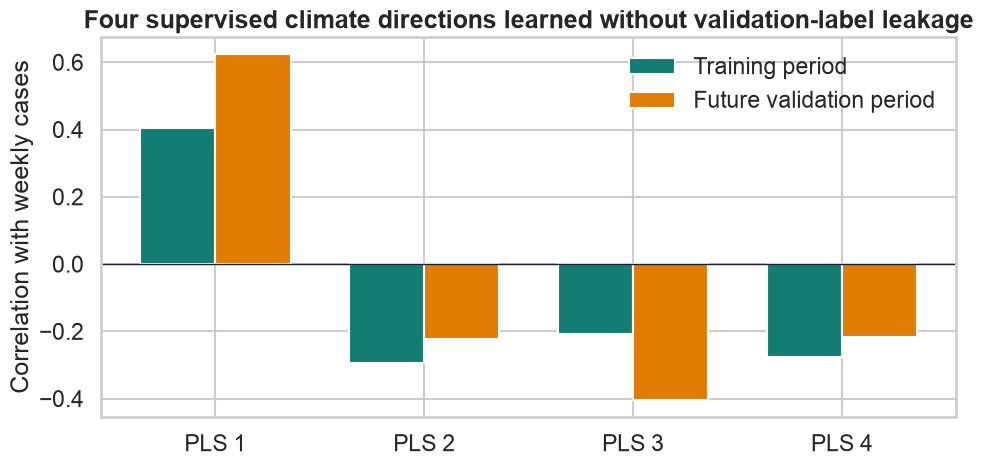

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
w = 0.36
ax.bar(x-w/2, pls_diagnostics["train correlation with cases"], w, color=TEAL, label="Training period")
ax.bar(x+w/2, pls_diagnostics["validation correlation with cases"], w, color=ORANGE, label="Future validation period")
ax.axhline(0, color=INK, lw=1)
ax.set(xticks=x, xticklabels=pls_diagnostics.component, ylabel="Correlation with weekly cases", title="Four supervised climate directions learned without validation-label leakage")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

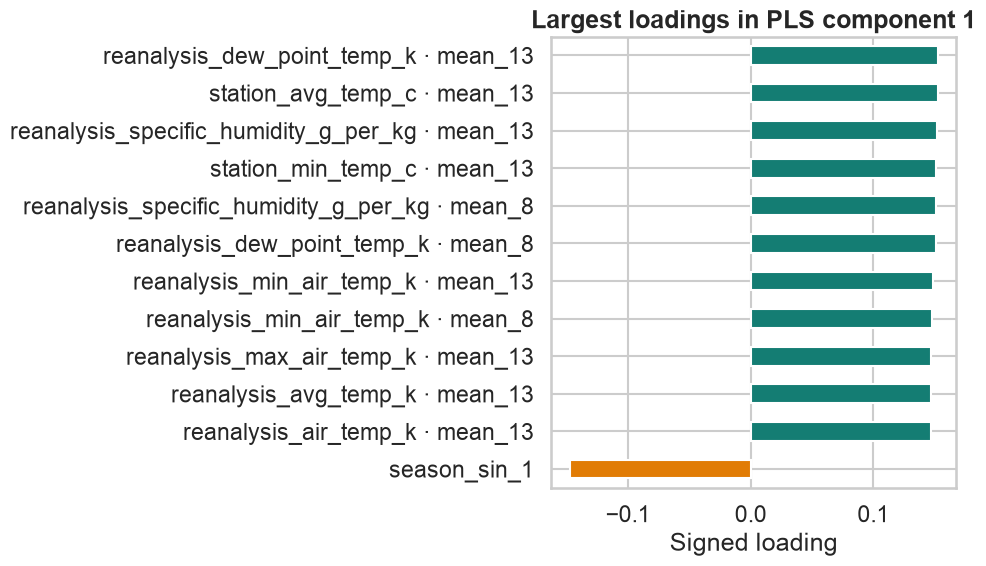

In [25]:
from feature_lag_mlp.config import WEATHER_FEATURES

summary_names = []
per_feature_names = [
    "current", "mean_2", "mean_4", "mean_8", "mean_13", "mean_26", "mean_52",
    "std_4", "std_13", "mean4_minus_mean13", "trend_13",
]
for feature in WEATHER_FEATURES:
    summary_names.extend([f"{feature} · {suffix}" for suffix in per_feature_names])
summary_names.extend(["season_sin_1", "season_cos_1", "season_sin_2", "season_cos_2"])

loadings = pd.Series(pls.x_loadings_[:, 0], index=summary_names)
top_component_one = loadings.reindex(loadings.abs().sort_values(ascending=False).head(12).index)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [TEAL if value >= 0 else ORANGE for value in top_component_one.sort_values().values]
top_component_one.sort_values().plot.barh(color=colors, ax=ax)
ax.set(title="Largest loadings in PLS component 1", xlabel="Signed loading", ylabel="")
plt.tight_layout()
plt.show()

### Why append PLS scores instead of replacing the summaries?

PLS constructs combinations of climate features that covary with the training target. Those four scores are appended to the 180 stable summaries:

```text
180 causal multiscale summaries
+ 4 standardized, fold-fitted PLS scores
= 184 San Juan inputs → Dense 100 → Dense 25 → prediction
```

Score-only and many-component variants were worse. Keeping the original summaries preserves nonlinear information; four scores add a small supervised view. PLS must be refitted inside every temporal fold so validation labels never influence the projection.

## 16. Complete model journey

,stage,hidden_mae,interpretation
0,Tree ensemble,22.5,climate memory and city-specific nonlinear models
1,V10 raw histories,19.3,continuous histories help
2,V11 improved dropout,19.1,regularization helps incrementally
3,Tuned raw histories,18.8,training refinements help incrementally
4,SJ multiscale + IQ raw,16.6,stable multiscale compression creates the larg...
5,Narrow multiscale (rejected),18.1,small local win was selection noise
6,Multiscale + 4 PLS scores,16.2,four target-aware directions refine the forecast


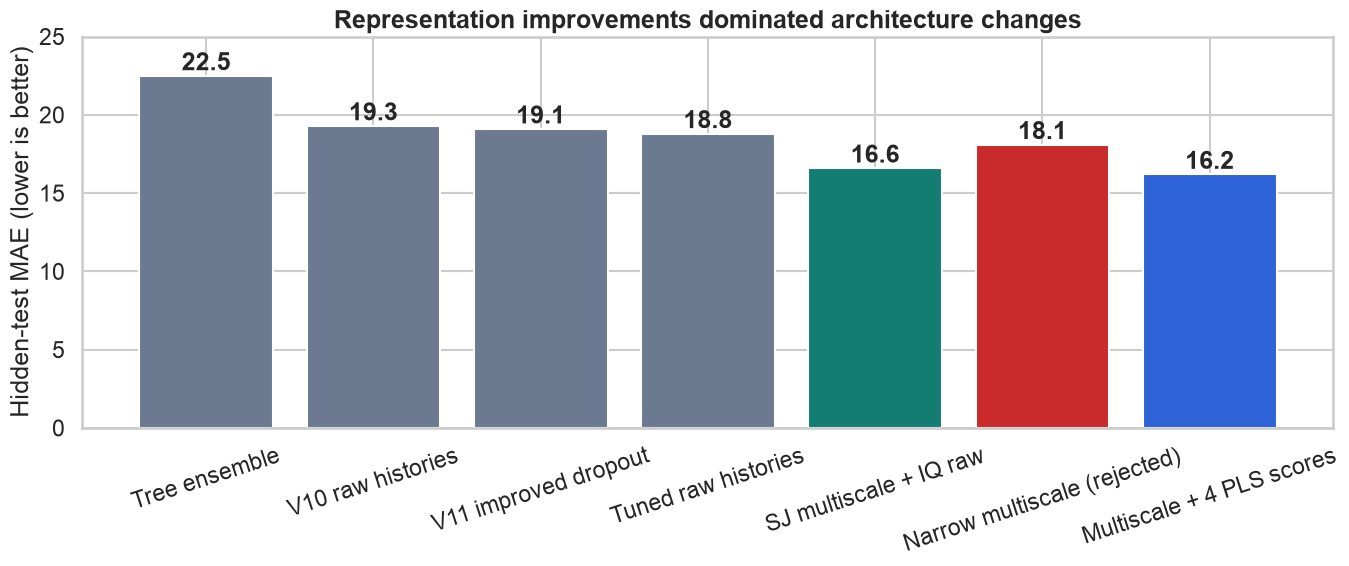

In [26]:
journey = pd.DataFrame(
    {
        "stage": [
            "Tree ensemble",
            "V10 raw histories",
            "V11 improved dropout",
            "Tuned raw histories",
            "SJ multiscale + IQ raw",
            "Narrow multiscale (rejected)",
            "Multiscale + 4 PLS scores",
        ],
        "hidden_mae": [22.5, 19.3, 19.1, 18.8, 16.6, 18.1, 16.2],
        "interpretation": [
            "climate memory and city-specific nonlinear models",
            "continuous histories help",
            "regularization helps incrementally",
            "training refinements help incrementally",
            "stable multiscale compression creates the large gain",
            "small local win was selection noise",
            "four target-aware directions refine the forecast",
        ],
    }
)
display(journey)

colors = [GRAY, GRAY, GRAY, GRAY, TEAL, RED, BLUE]
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(journey.stage, journey.hidden_mae, color=colors)
ax.set(title="Representation improvements dominated architecture changes", ylabel="Hidden-test MAE (lower is better)")
ax.tick_params(axis="x", rotation=18)
ax.set_ylim(0, 25)
for bar, value in zip(bars, journey.hidden_mae):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.35, f"{value:.1f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 17. Model-selection lesson: a small local win is not proof

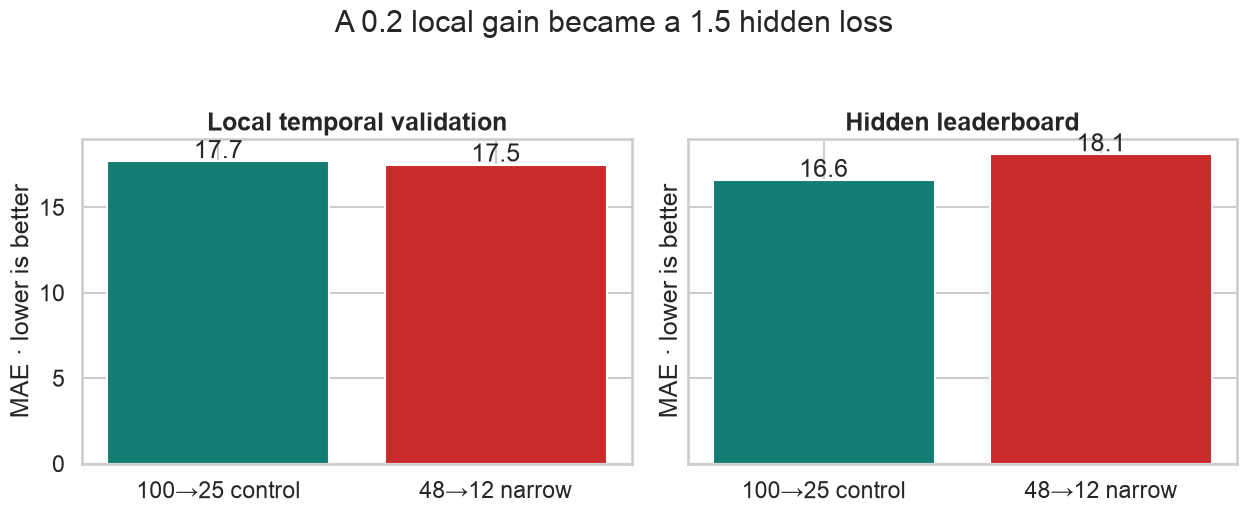

In [27]:
selection_trap = pd.DataFrame(
    {
        "model": ["100→25 control", "48→12 narrow"],
        "local_temporal_mae": [17.7, 17.5],
        "hidden_mae": [16.6, 18.1],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, metric, title in [
    (axes[0], "local_temporal_mae", "Local temporal validation"),
    (axes[1], "hidden_mae", "Hidden leaderboard"),
]:
    bars = ax.bar(selection_trap.model, selection_trap[metric], color=[TEAL, RED])
    ax.set(title=title, ylabel="MAE · lower is better")
    for bar, value in zip(bars, selection_trap[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, value + 0.18, f"{value:.1f}", ha="center")
fig.suptitle("A 0.2 local gain became a 1.5 hidden loss", y=1.04)
fig.tight_layout()
plt.show()

The narrow network was chosen after searching many candidates. Its 0.224 local advantage was smaller than fold/seed variation, and its outbreak MAE was worse. The hidden reversal is classic model-selection noise.

The final workflow therefore uses:

- expanding temporal folds;
- multiple seeds for neural candidates;
- overall, outbreak, bias, and amplitude diagnostics;
- stability penalties and worst-fold checks;
- bounded ablations with a clear hypothesis;
- the hidden leaderboard only as final external evidence, not as the tuning loop.

## 18. Final architecture and conclusions

### Final city-hybrid system

```text
San Juan
weather history
→ 180 multiscale summaries
→ 4 fold-fitted standardized PLS scores
→ 184 inputs
→ Dense(100, SELU) → Dropout → Dense(25, SELU) → Dropout → output

Iquitos
feature-specific raw climate histories
→ 380 inputs
→ Dense(70, SELU) → Dropout → Dense(18, SELU) → Dropout → output
```

### Main conclusions

1. **Treat the cities separately.** Their scale, sample size, seasonality, and climate distributions differ.
2. **Use causal past-only histories.** Same-week weather misses delayed and accumulated effects.
3. **Diagnose outbreaks separately.** Average MAE can hide catastrophic smoothing of rare peaks.
4. **Control variance before increasing complexity.** Extra Trees provided a strong, regularized nonlinear baseline.
5. **Representation mattered more than architecture.** Raw histories helped; multiscale compression helped much more.
6. **Use supervision sparingly in feature extraction.** Four leakage-safe PLS directions improved the strong representation without replacing it.
7. **Treat tiny validation improvements as uncertainty.** The 48→12 experiment shows how easily search noise can reverse.

## 19. Optional presentation summary slides

The next two figures condense the preprocessing and feature-engineering choices
into slide-ready diagrams. They intentionally repeat earlier evidence in a more
compact form for oral presentation.

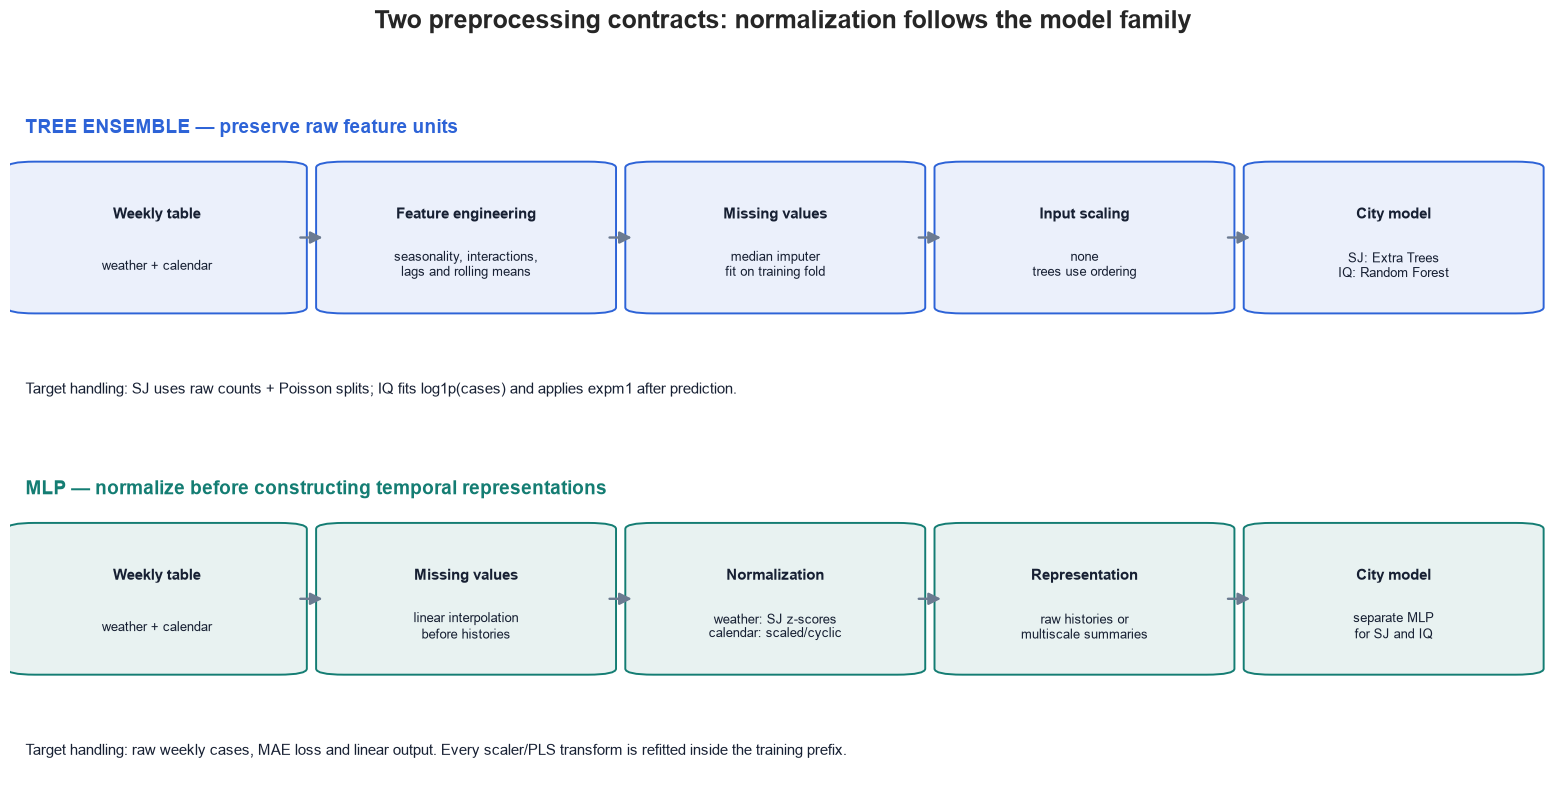

In [28]:
from matplotlib.patches import FancyBboxPatch


def pipeline_box(ax, x, y, width, height, title, detail, color):
    patch = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.012,rounding_size=0.018",
        linewidth=1.4, edgecolor=color, facecolor=color + "18",
        transform=ax.transAxes,
    )
    ax.add_patch(patch)
    ax.text(x + width / 2, y + height * 0.66, title, ha="center", va="center",
            transform=ax.transAxes, fontsize=11, fontweight="bold", color=INK)
    ax.text(x + width / 2, y + height * 0.31, detail, ha="center", va="center",
            transform=ax.transAxes, fontsize=9.2, color=INK, linespacing=1.25)


def pipeline_arrow(ax, x1, x2, y):
    ax.annotate(
        "", xy=(x2, y), xytext=(x1, y), xycoords=ax.transAxes,
        arrowprops={"arrowstyle": "-|>", "lw": 1.7, "color": GRAY},
    )


fig, axes = plt.subplots(2, 1, figsize=(16, 8))
lanes = [
    (
        axes[0], "TREE ENSEMBLE — preserve raw feature units", BLUE,
        [
            ("Weekly table", "weather + calendar"),
            ("Feature engineering", "seasonality, interactions,\nlags and rolling means"),
            ("Missing values", "median imputer\nfit on training fold"),
            ("Input scaling", "none\ntrees use ordering"),
            ("City model", "SJ: Extra Trees\nIQ: Random Forest"),
        ],
        "Target handling: SJ uses raw counts + Poisson splits; IQ fits log1p(cases) and applies expm1 after prediction.",
    ),
    (
        axes[1], "MLP — normalize before constructing temporal representations", TEAL,
        [
            ("Weekly table", "weather + calendar"),
            ("Missing values", "linear interpolation\nbefore histories"),
            ("Normalization", "weather: SJ z-scores\ncalendar: scaled/cyclic"),
            ("Representation", "raw histories or\nmultiscale summaries"),
            ("City model", "separate MLP\nfor SJ and IQ"),
        ],
        "Target handling: raw weekly cases, MAE loss and linear output. Every scaler/PLS transform is refitted inside the training prefix.",
    ),
]

for ax, lane_title, lane_color, steps, footer in lanes:
    ax.set_axis_off()
    ax.text(0.01, 0.93, lane_title, transform=ax.transAxes, fontsize=14,
            fontweight="bold", color=lane_color, va="top")
    xs = [0.01, 0.21, 0.41, 0.61, 0.81]
    width, height, y = 0.17, 0.43, 0.36
    for index, ((title, detail), x) in enumerate(zip(steps, xs)):
        pipeline_box(ax, x, y, width, height, title, detail, lane_color)
        if index < len(xs) - 1:
            pipeline_arrow(ax, x + width + 0.006, xs[index + 1] - 0.006, y + height / 2)
    ax.text(0.01, 0.12, footer, transform=ax.transAxes, fontsize=10.5,
            color=INK, va="center")

fig.suptitle("Two preprocessing contracts: normalization follows the model family", y=1.01, fontsize=18, fontweight="bold")
fig.tight_layout()
plt.show()

/var/folders/dd/3f_45y011kbdbxh81pzc68640000gn/T/ipykernel_63535/414745292.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


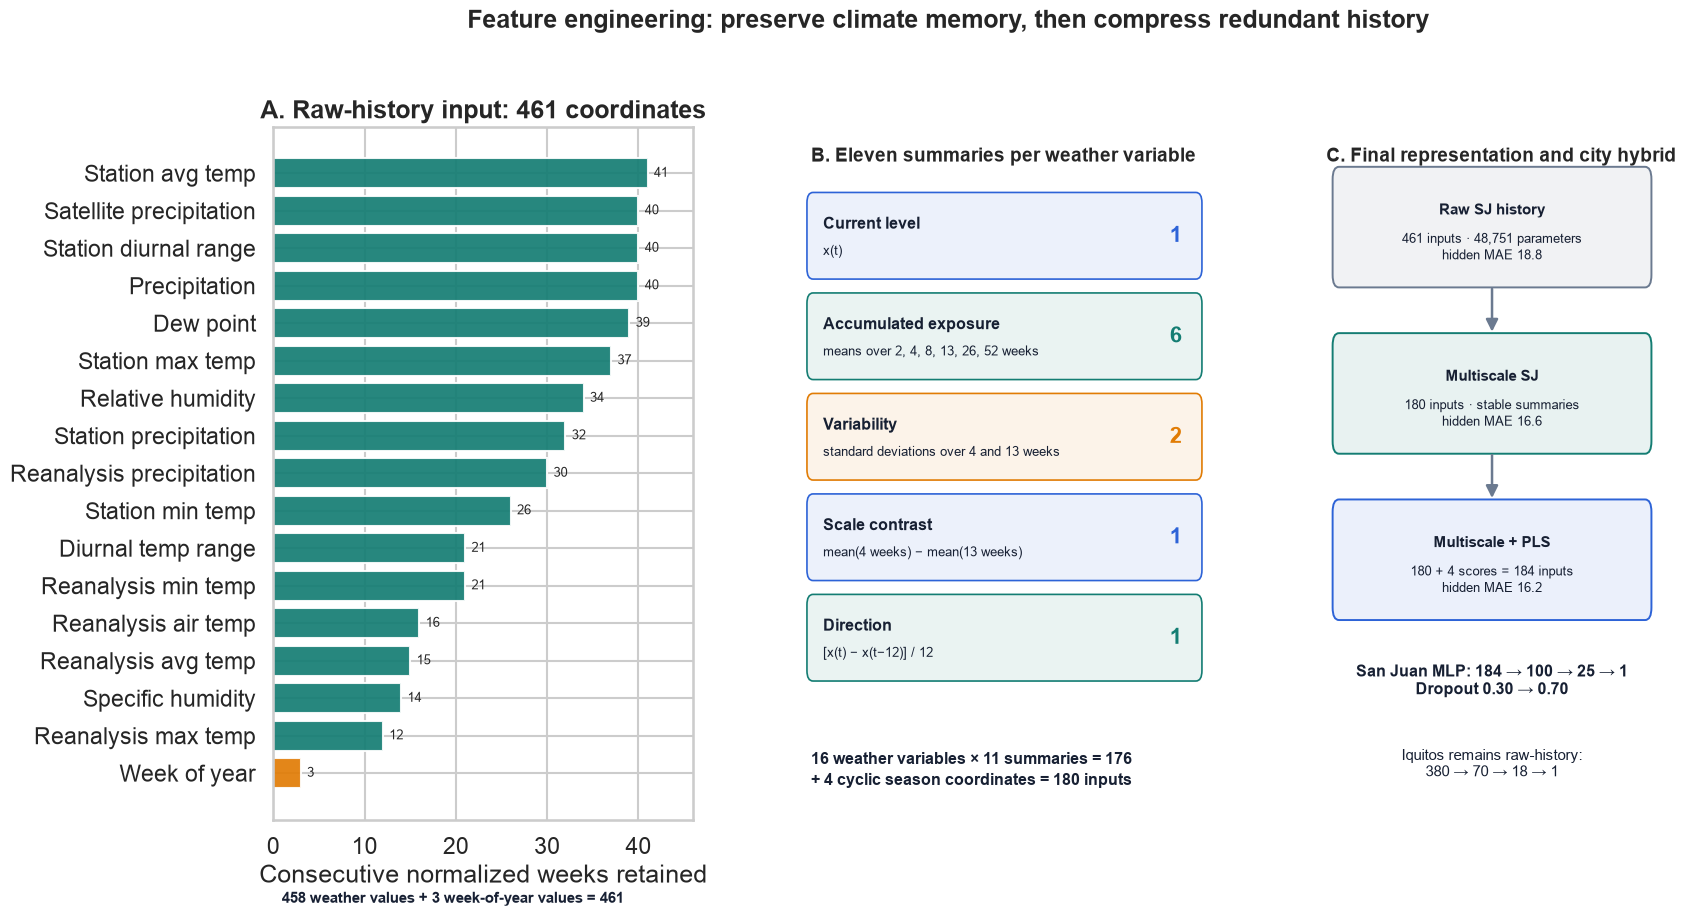

In [29]:
from feature_lag_mlp.config import LAG_WINDOWS

short_names = {
    "precipitation_amt_mm": "Precipitation",
    "reanalysis_air_temp_k": "Reanalysis air temp",
    "reanalysis_avg_temp_k": "Reanalysis avg temp",
    "reanalysis_dew_point_temp_k": "Dew point",
    "reanalysis_max_air_temp_k": "Reanalysis max temp",
    "reanalysis_min_air_temp_k": "Reanalysis min temp",
    "reanalysis_precip_amt_kg_per_m2": "Reanalysis precipitation",
    "reanalysis_relative_humidity_percent": "Relative humidity",
    "reanalysis_sat_precip_amt_mm": "Satellite precipitation",
    "reanalysis_specific_humidity_g_per_kg": "Specific humidity",
    "reanalysis_tdtr_k": "Diurnal temp range",
    "station_avg_temp_c": "Station avg temp",
    "station_diur_temp_rng_c": "Station diurnal range",
    "station_max_temp_c": "Station max temp",
    "station_min_temp_c": "Station min temp",
    "station_precip_mm": "Station precipitation",
    "weekofyear": "Week of year",
}

sj_windows = pd.Series(LAG_WINDOWS["sj"]).rename(index=short_names).sort_values()

fig = plt.figure(figsize=(18, 9))
grid = fig.add_gridspec(1, 3, width_ratios=[1.25, 1.20, 1.05], wspace=0.28)

# Panel A: exact composition of the 461 raw coordinates.
ax0 = fig.add_subplot(grid[0, 0])
bar_colors = [ORANGE if label == "Week of year" else TEAL for label in sj_windows.index]
bars = ax0.barh(sj_windows.index, sj_windows.values, color=bar_colors, alpha=0.92)
for bar, value in zip(bars, sj_windows.values):
    ax0.text(value + 0.7, bar.get_y() + bar.get_height()/2, str(value), va="center", fontsize=9)
ax0.set(xlim=(0, 46), xlabel="Consecutive normalized weeks retained", title="A. Raw-history input: 461 coordinates")
ax0.text(0.02, -0.12, "458 weather values + 3 week-of-year values = 461",
         transform=ax0.transAxes, fontsize=11, fontweight="bold", color=INK)

# Panel B: the 11 summaries calculated for every weather variable.
ax1 = fig.add_subplot(grid[0, 1])
ax1.set_axis_off()
summary_rows = [
    ("Current level", "x(t)", "1", BLUE),
    ("Accumulated exposure", "means over 2, 4, 8, 13, 26, 52 weeks", "6", TEAL),
    ("Variability", "standard deviations over 4 and 13 weeks", "2", ORANGE),
    ("Scale contrast", "mean(4 weeks) − mean(13 weeks)", "1", BLUE),
    ("Direction", "[x(t) − x(t−12)] / 12", "1", TEAL),
]
ax1.text(0.02, 0.97, "B. Eleven summaries per weather variable", transform=ax1.transAxes,
         fontsize=14, fontweight="bold", va="top")
for row, (name, detail, count, color) in enumerate(summary_rows):
    y = 0.79 - row * 0.145
    patch = FancyBboxPatch(
        (0.02, y), 0.96, 0.105, boxstyle="round,pad=0.01,rounding_size=0.015",
        linewidth=1.2, edgecolor=color, facecolor=color + "16", transform=ax1.transAxes,
    )
    ax1.add_patch(patch)
    ax1.text(0.05, y + 0.069, name, transform=ax1.transAxes, fontsize=11.2,
             fontweight="bold", va="center", color=INK)
    ax1.text(0.05, y + 0.030, detail, transform=ax1.transAxes, fontsize=9.7,
             va="center", color=INK)
    ax1.text(0.94, y + 0.052, count, transform=ax1.transAxes, ha="right", va="center",
             fontsize=16, fontweight="bold", color=color)
ax1.text(0.02, 0.05, "16 weather variables × 11 summaries = 176\n+ 4 cyclic season coordinates = 180 inputs",
         transform=ax1.transAxes, fontsize=11.5, fontweight="bold", color=INK, linespacing=1.5)

# Panel C: dimension and model evolution.
ax2 = fig.add_subplot(grid[0, 2])
ax2.set_axis_off()
ax2.text(0.03, 0.97, "C. Final representation and city hybrid", transform=ax2.transAxes,
         fontsize=14, fontweight="bold", va="top")
evolution = [
    (0.78, "Raw SJ history", "461 inputs · 48,751 parameters\nhidden MAE 18.8", GRAY),
    (0.54, "Multiscale SJ", "180 inputs · stable summaries\nhidden MAE 16.6", TEAL),
    (0.30, "Multiscale + PLS", "180 + 4 scores = 184 inputs\nhidden MAE 16.2", BLUE),
]
for index, (y, title, detail, color) in enumerate(evolution):
    pipeline_box(ax2, 0.06, y, 0.88, 0.15, title, detail, color)
    if index < len(evolution) - 1:
        ax2.annotate("", xy=(0.50, evolution[index + 1][0] + 0.16), xytext=(0.50, y - 0.01),
                     xycoords=ax2.transAxes, arrowprops={"arrowstyle": "-|>", "lw": 1.8, "color": GRAY})
ax2.text(0.50, 0.20, "San Juan MLP: 184 → 100 → 25 → 1\nDropout 0.30 → 0.70",
         transform=ax2.transAxes, ha="center", va="center", fontsize=11.5,
         fontweight="bold", color=INK)
ax2.text(0.50, 0.08, "Iquitos remains raw-history:\n380 → 70 → 18 → 1",
         transform=ax2.transAxes, ha="center", va="center", fontsize=10.5, color=INK)

fig.suptitle("Feature engineering: preserve climate memory, then compress redundant history", y=1.01,
             fontsize=18, fontweight="bold")
fig.tight_layout()
plt.show()

**How to present these two slides:** first emphasize that preprocessing is
model-dependent—trees retain raw units, while MLPs require normalized inputs.
Then explain that the successful feature-engineering change did not discard
history; it replaced hundreds of correlated weekly coordinates with explicit
level, exposure, variability, contrast, and trend summaries at several scales.

## 20. Reproducing the expensive final experiments

In [30]:
commands = {
    "Tree baseline": "uv run src/train_tree_ensemble.py",
    "Raw-history MLP": "uv run src/train_feature_lag_mlp.py --profile tuned --seed 42",
    "Representation ablation": "uv run src/experiment_feature_lag_mlp_representation.py",
    "Multiscale 16.6 model": "uv run src/train_best_submission.py",
    "PLS experiment (when present on the leaderboard branch)": "uv run src/experiment_feature_lag_mlp_pls.py",
}
pd.Series(commands, name="command").to_frame()

,command
Tree baseline,uv run src/train_tree_ensemble.py
Raw-history MLP,uv run src/train_feature_lag_mlp.py --profile ...
Representation ablation,uv run src/experiment_feature_lag_mlp_represen...
Multiscale 16.6 model,uv run src/train_best_submission.py
PLS experiment (when present on the leaderboard branch),uv run src/experiment_feature_lag_mlp_pls.py


### Suggested presentation ending

> Our first models treated each row mainly as a description of the current week. Error analysis showed that this was precisely where the worst mistakes occurred: outbreak peaks appeared after climate conditions had accumulated over time. Extra Trees reduced variance and established a strong nonlinear baseline, but the major breakthrough came from representation. Continuous histories improved the MLP to the 19-MAE range; multiscale summaries then compressed those histories into stable short-, medium-, and long-term signals, reaching 16.6. Finally, four leakage-safe PLS scores added a small target-aware view and reached 16.2. The lesson is that for dengue forecasting, describing climate memory correctly mattered more than making the predictor larger.